# 📊 Top 100 YouTube Channels - Advanced Analysis

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20,20)


In [2]:

df = pd.read_csv('youtube_top_100_by_subscribers.csv')
df.head()


,rank,channel,subscribers,video_views,uploads
0,1,MrBeast,475M,117.01B,962
1,2,T-Series,311M,336.49B,25.8K
2,3,Cocomelon - Nursery Rhymes,200M,219.82B,1.96K
3,4,YouTube Movies,197M,0,0
4,5,SET India,189M,187.39B,168.75K


## Data Cleaning

In [3]:
df = df[~df['channel'].isin(['YouTube Movies', 'Sports', 'Music', 'Gaming'])]

df['subscribers'] = df['subscribers'].str.replace('M','').astype(float)

df['video_views'] = df['video_views'].str.replace('B','').str.replace('M','')
df['video_views'] = pd.to_numeric(df['video_views'], errors='coerce')

df['uploads'] = df['uploads'].str.replace('K','')
df['uploads'] = pd.to_numeric(df['uploads'], errors='coerce')

df = df.reset_index(drop=True)


## All Channels Ranking

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sa

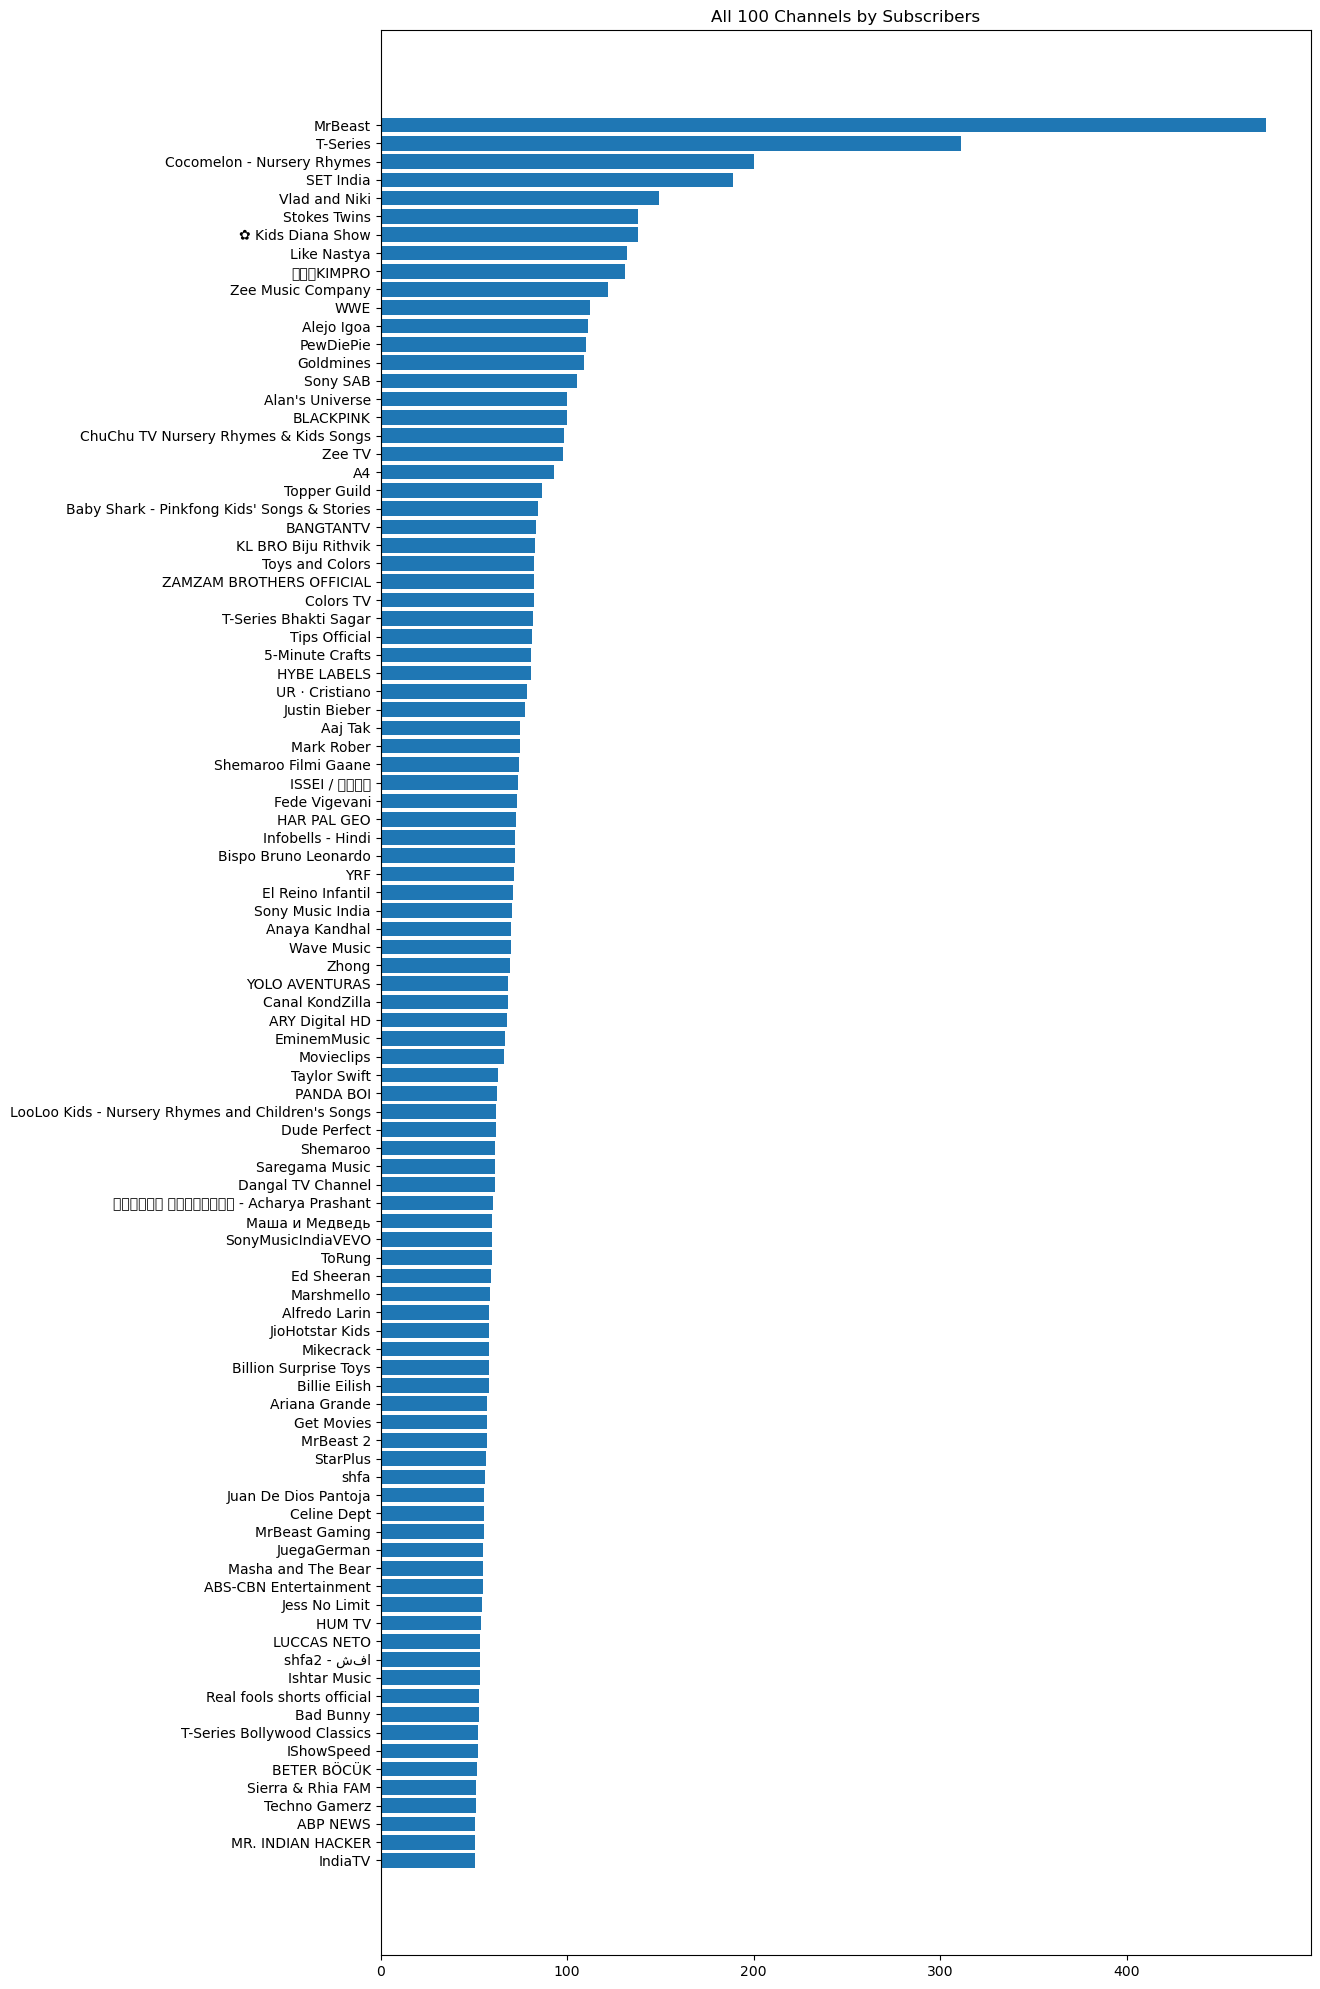

In [4]:

df_sorted = df.sort_values(by='subscribers', ascending=True)

plt.figure(figsize=(12,25))
plt.barh(df_sorted['channel'], df_sorted['subscribers'])
plt.title("All 100 Channels by Subscribers")
plt.show()


## Efficiency Analysis

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


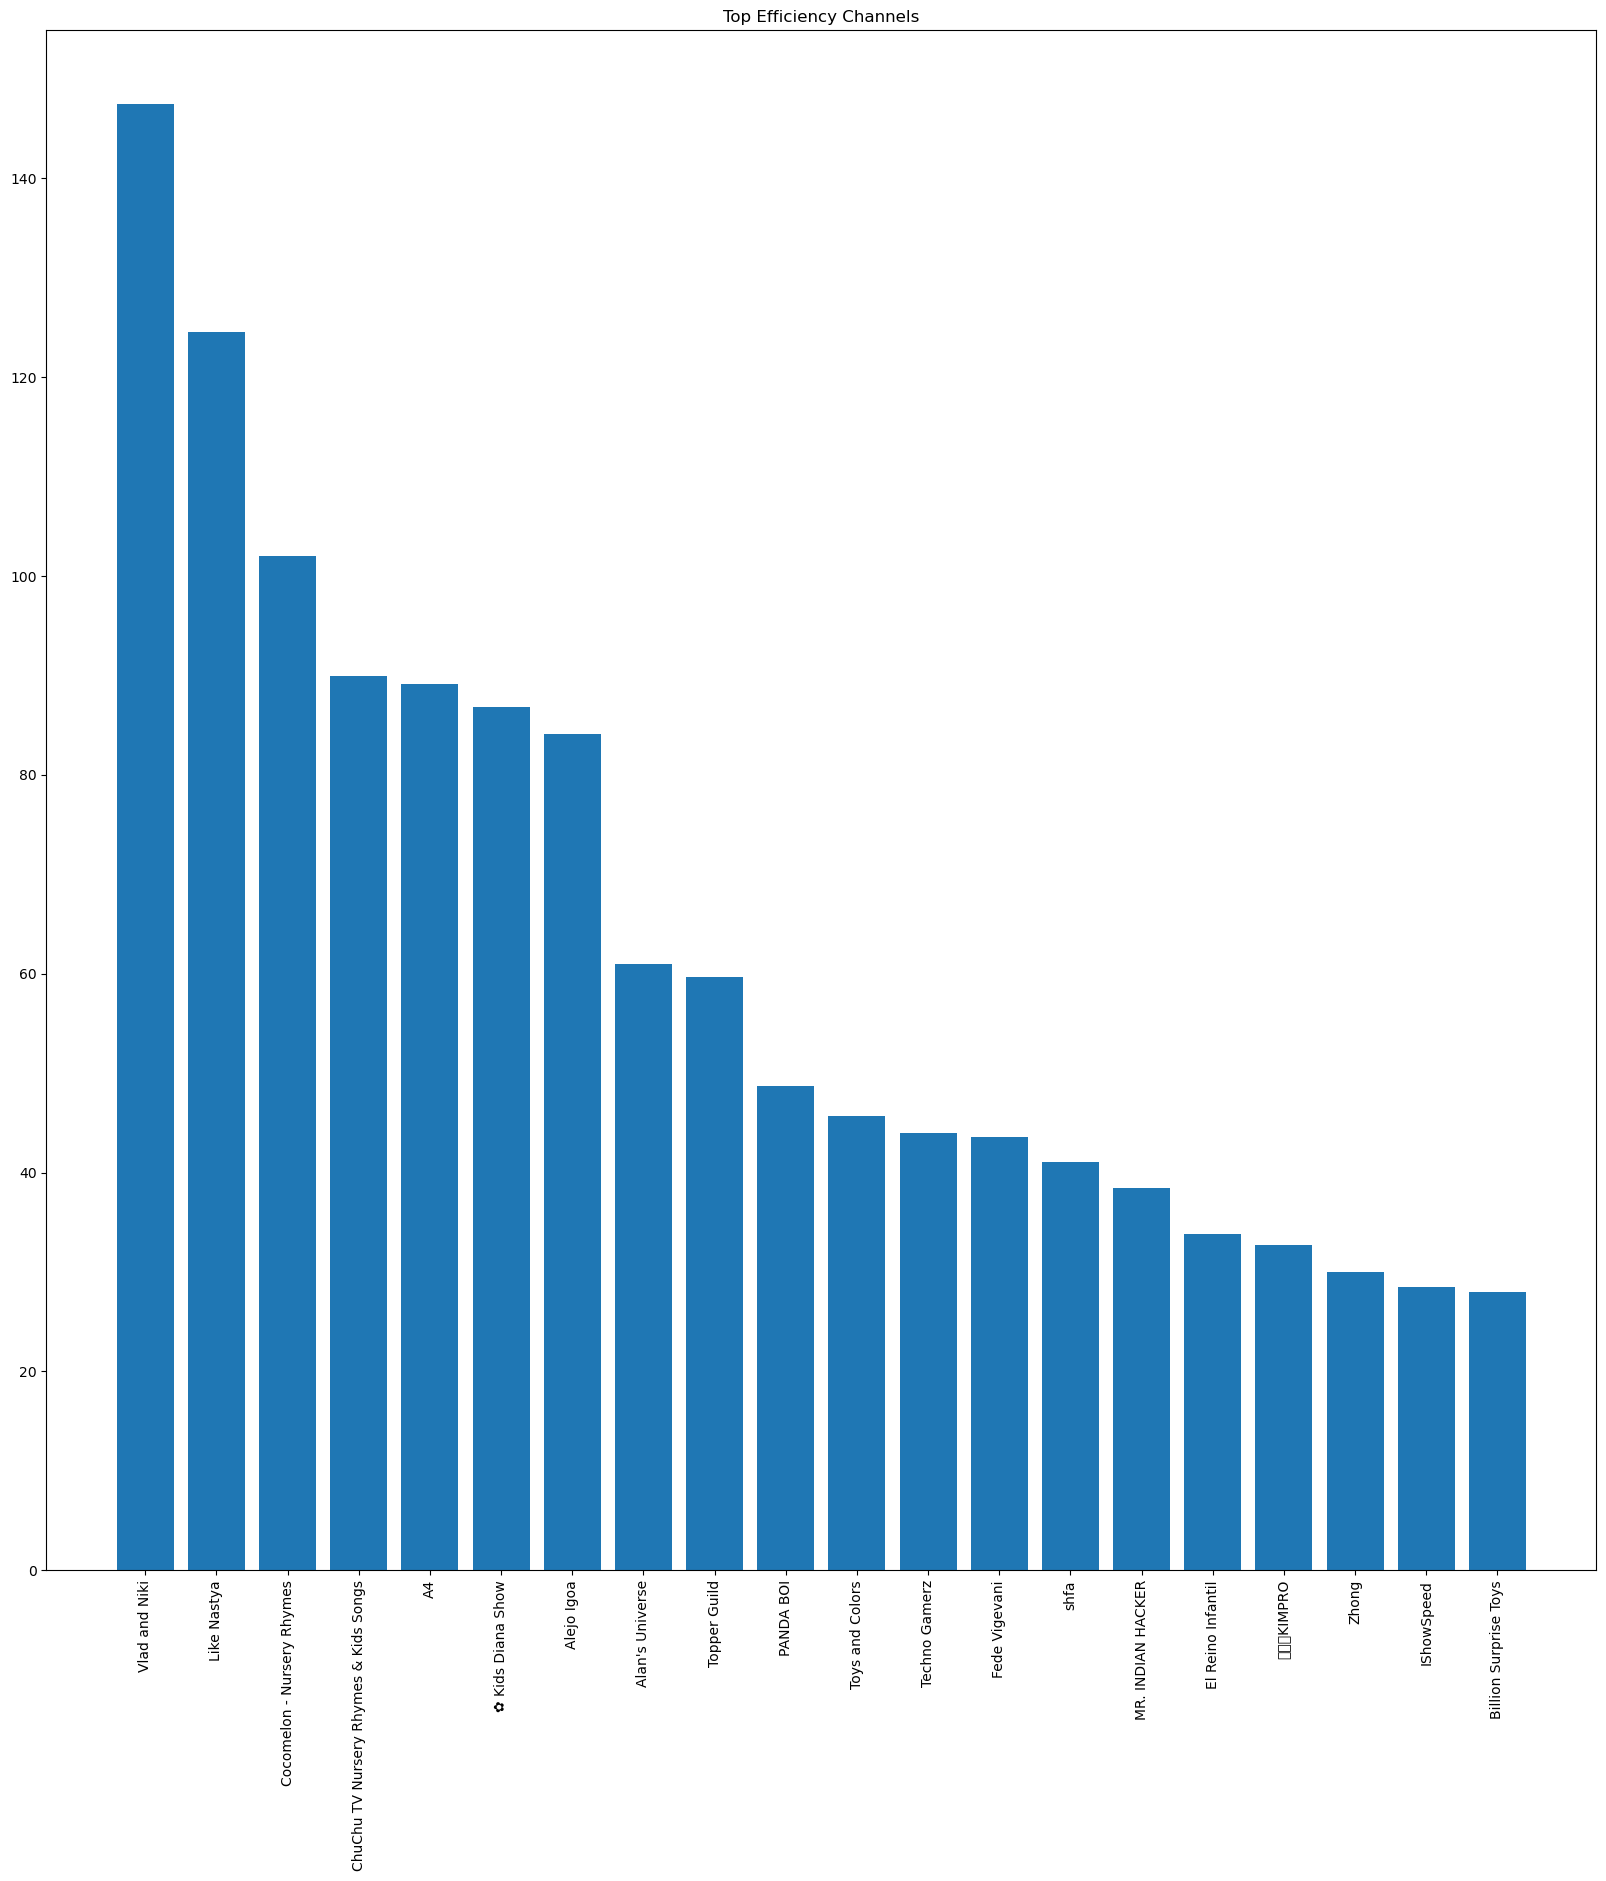

In [5]:

df['subs_per_upload'] = df['subscribers'] / df['uploads']

eff = df.sort_values(by='subs_per_upload', ascending=False).head(20)

plt.figure()
plt.bar(eff['channel'], eff['subs_per_upload'])
plt.xticks(rotation=90)
plt.title("Top Efficiency Channels")
plt.show()


## Scatter Analysis

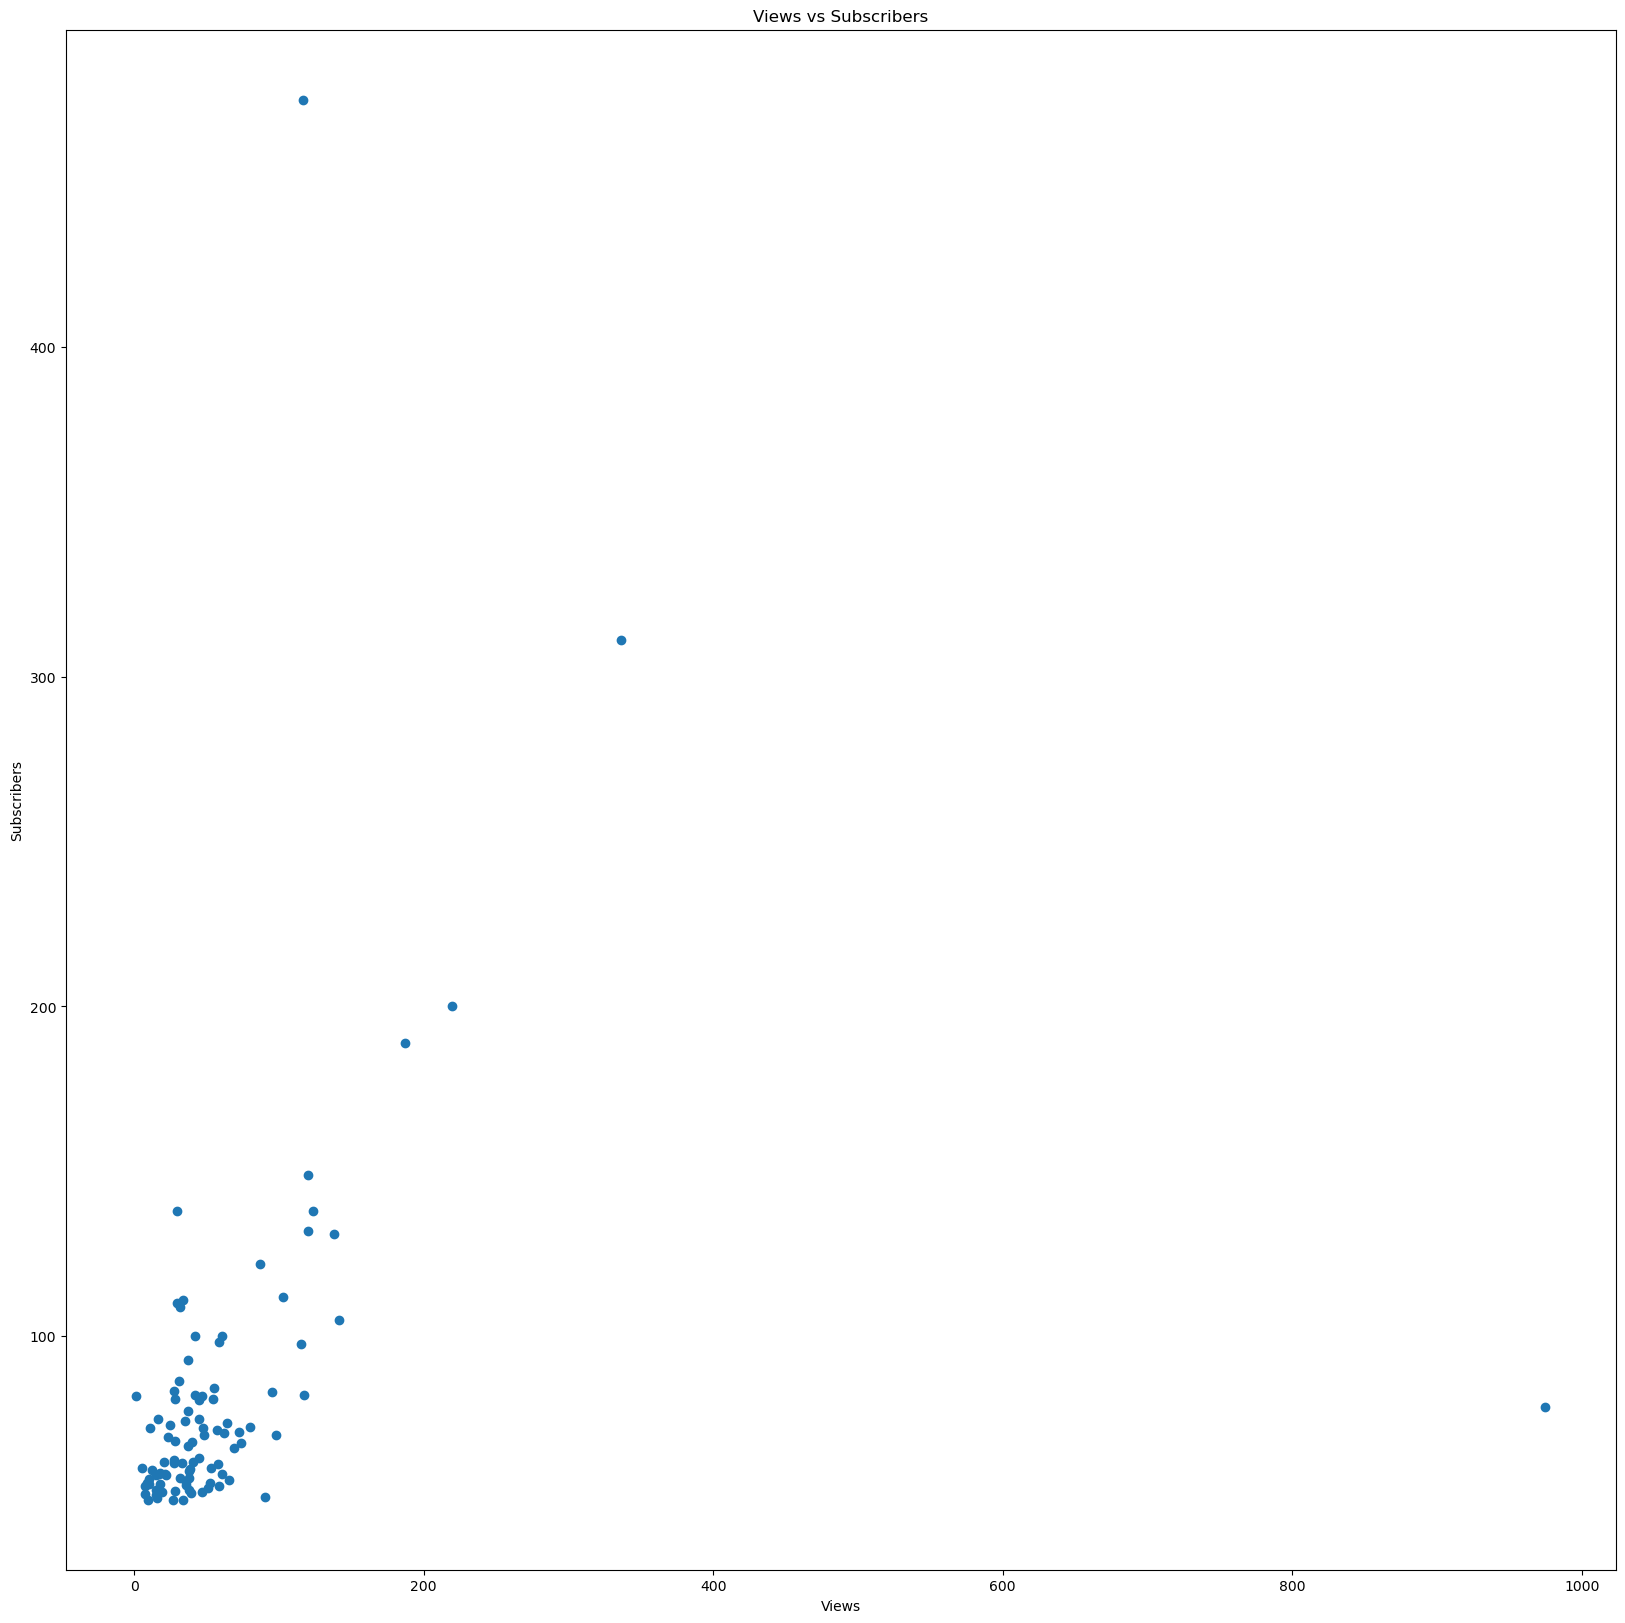

In [6]:

plt.figure()
plt.scatter(df['video_views'], df['subscribers'])
plt.xlabel("Views")
plt.ylabel("Subscribers")
plt.title("Views vs Subscribers")
plt.show()


## Distribution

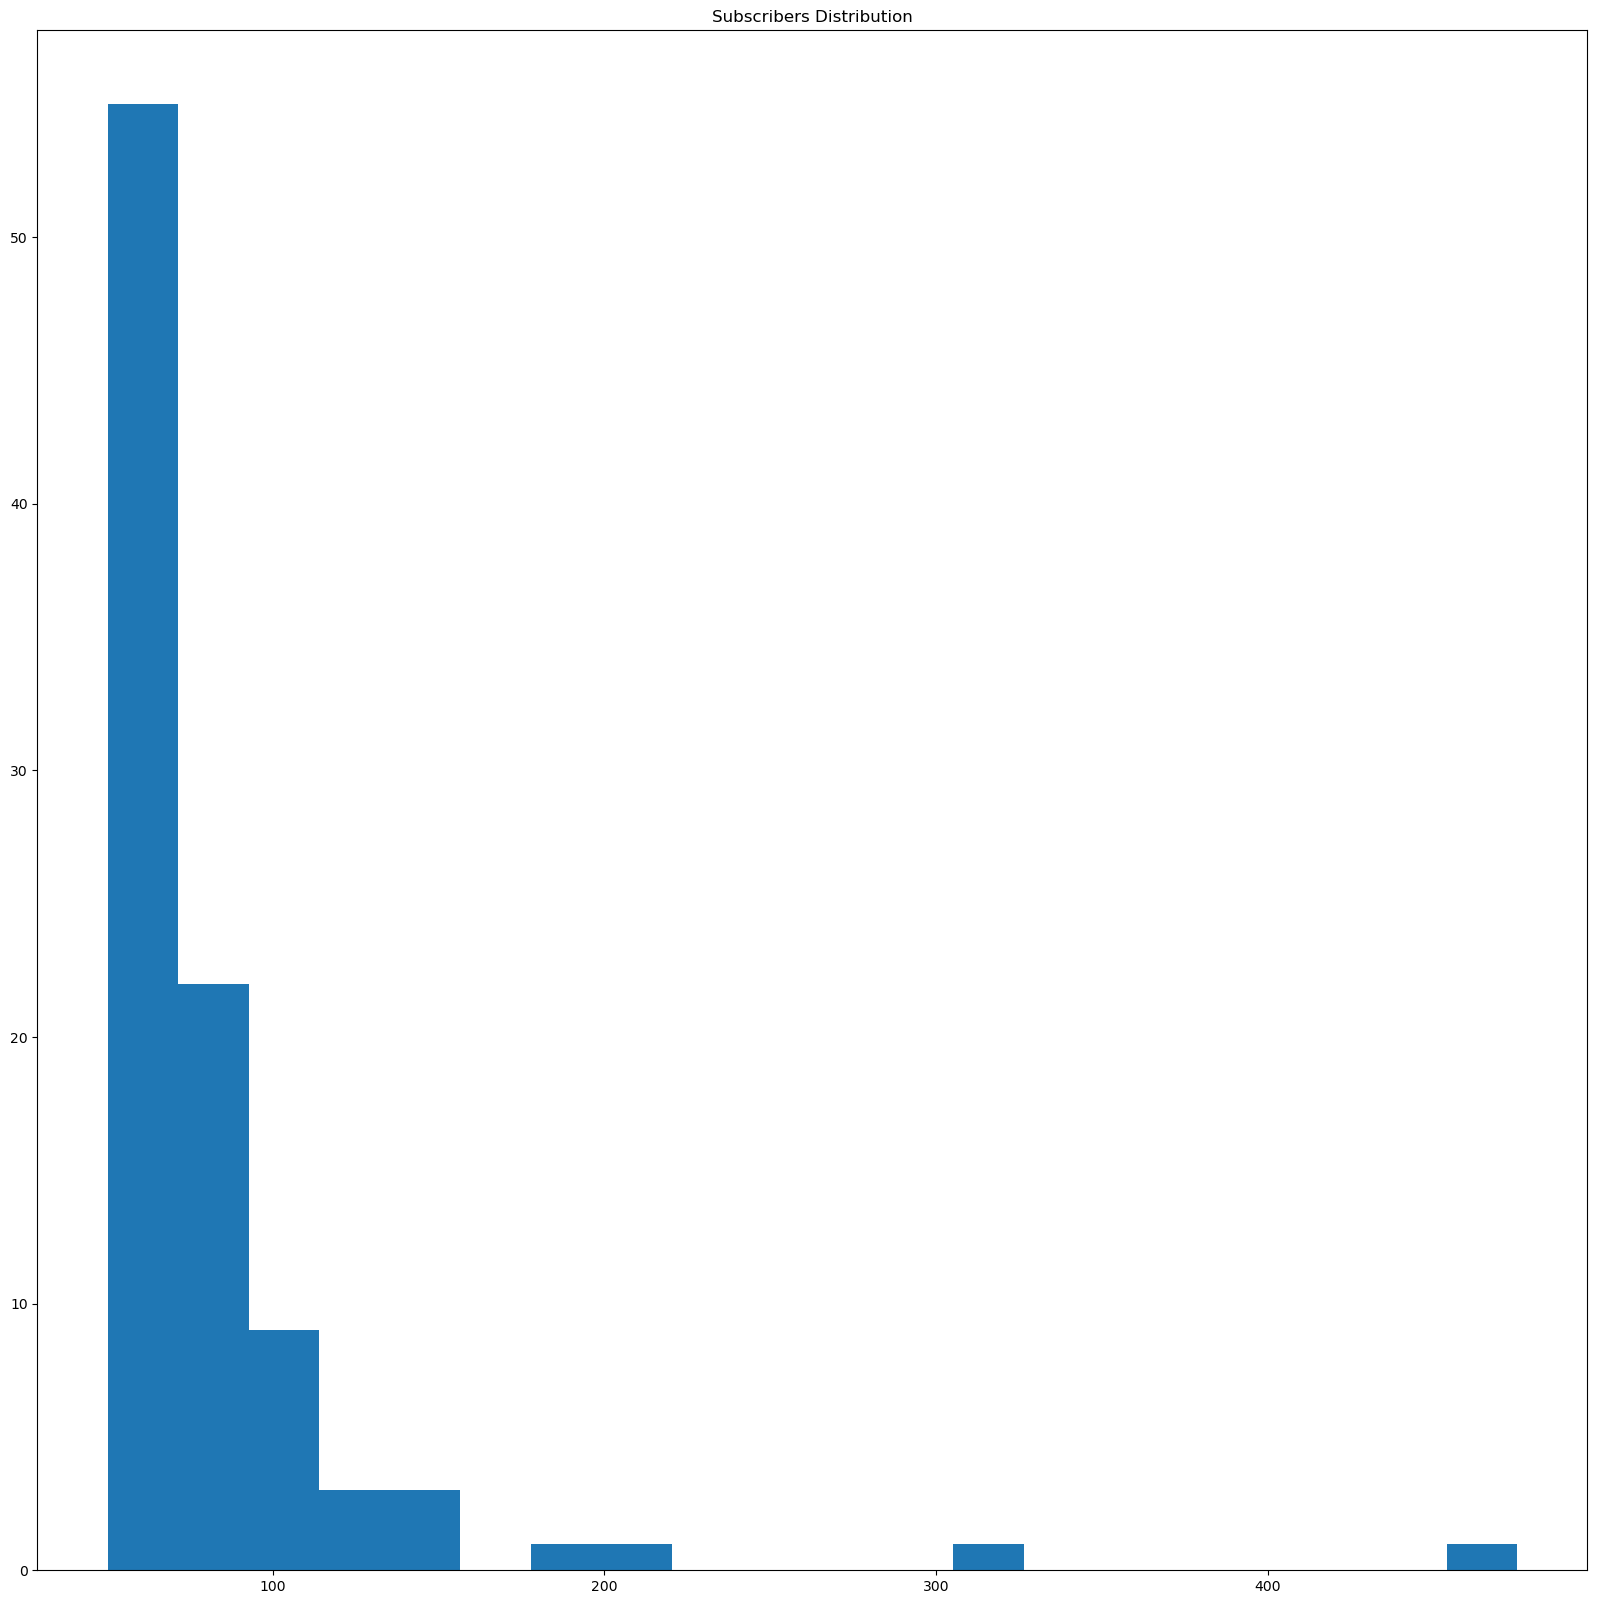

In [7]:

plt.figure()
plt.hist(df['subscribers'], bins=20)
plt.title("Subscribers Distribution")
plt.show()


## Correlation

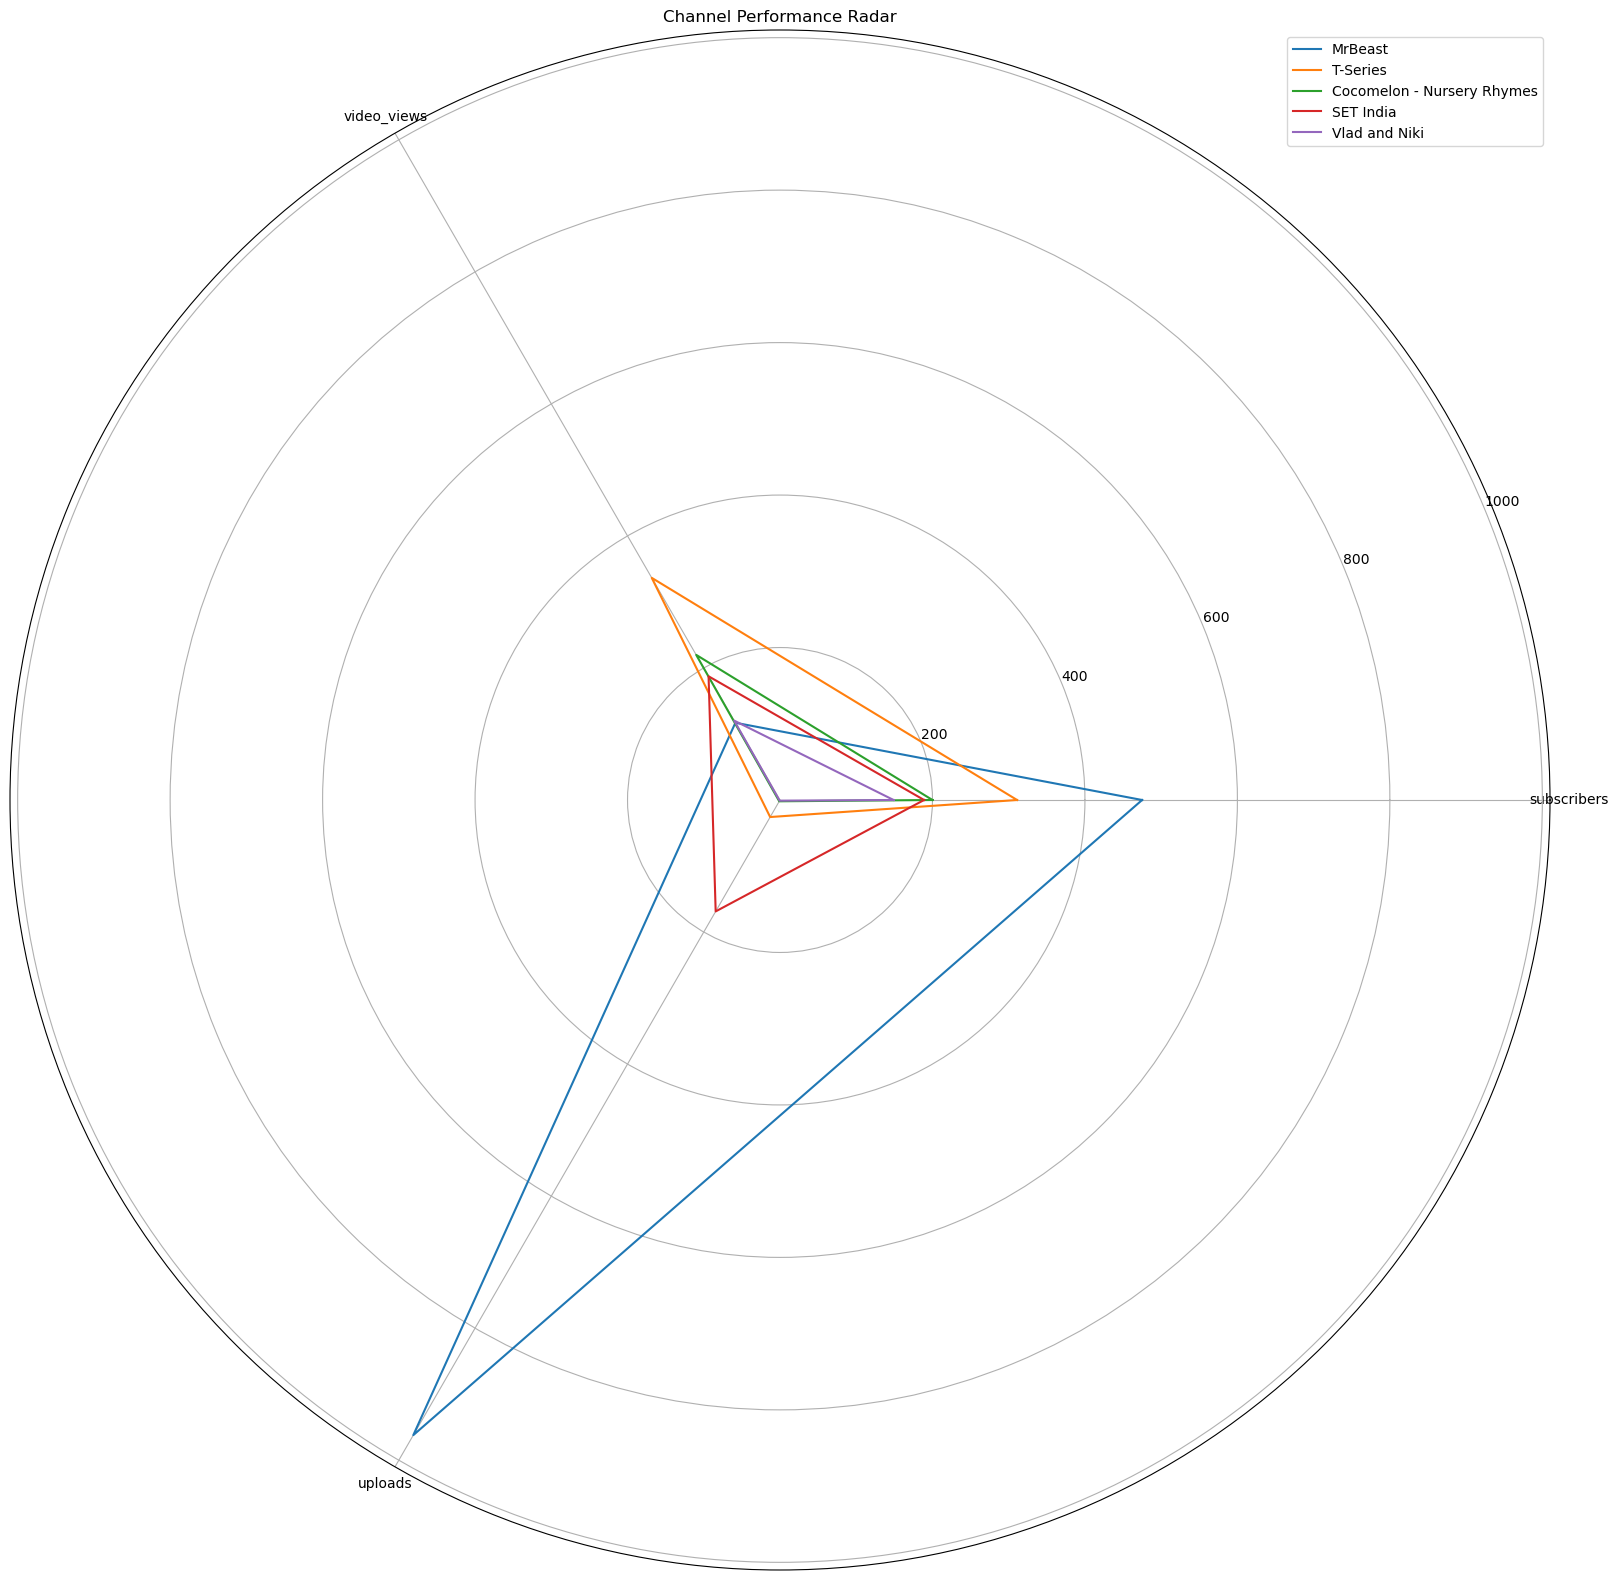

In [8]:
import numpy as np
import matplotlib.pyplot as plt


top5 = df.sort_values(by='subscribers', ascending=False).head(5)

categories = ['subscribers', 'video_views', 'uploads']
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]


for i, row in top5.iterrows():
    values = row[categories].values.tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=row['channel'])

plt.xticks(angles[:-1], categories)
plt.title("Channel Performance Radar")
plt.legend(loc='upper right')
plt.show()

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12387 (\N{HIRAGANA LETTER SMALL TU}) missing from font(s

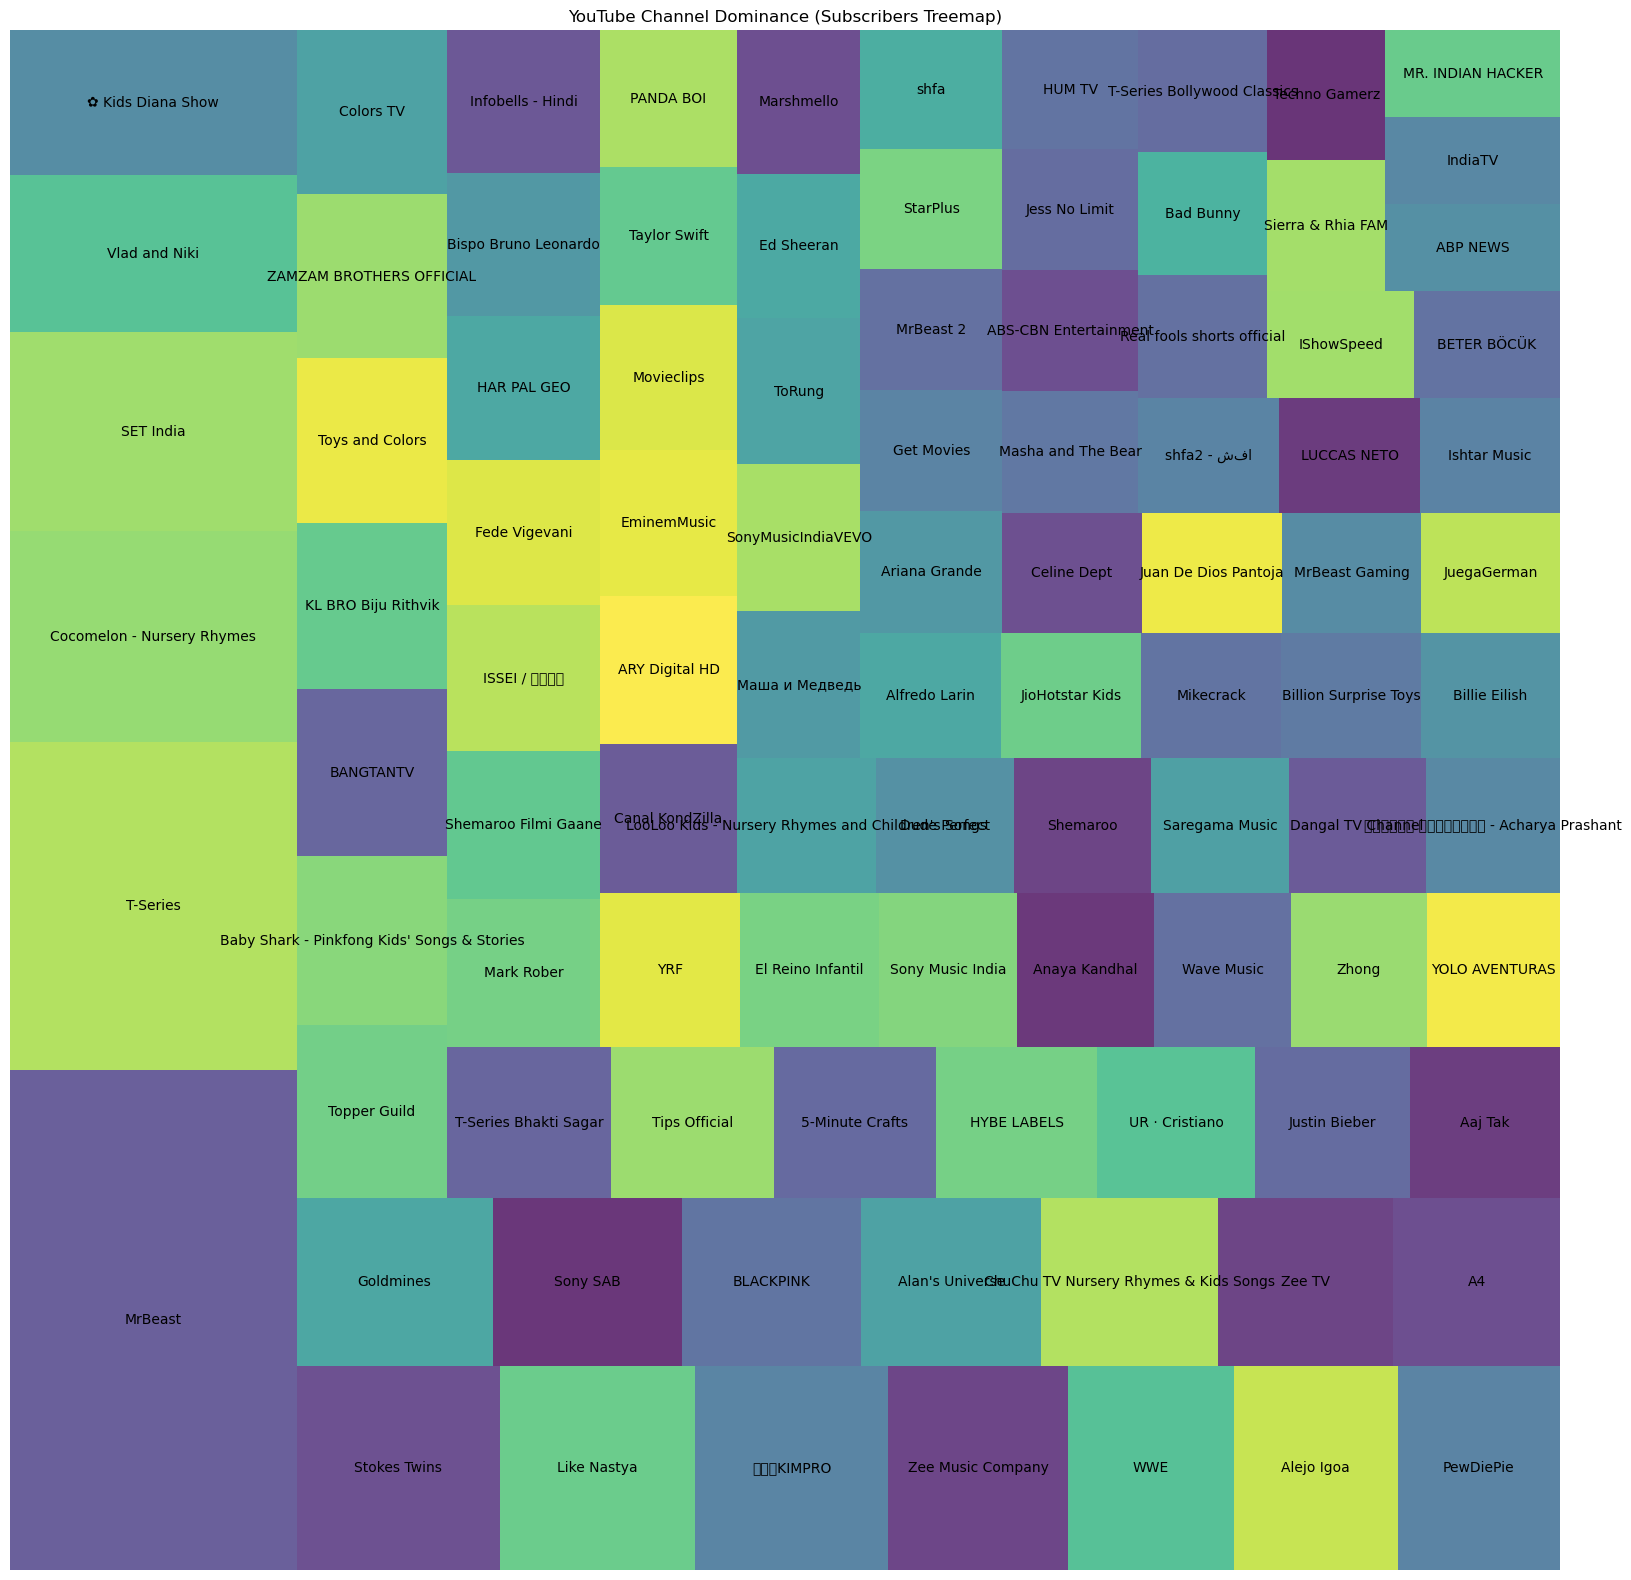

In [9]:
import squarify

df_sorted = df.sort_values(by='subscribers', ascending=False)


squarify.plot(
    sizes=df_sorted['subscribers'],
    label=df_sorted['channel'],
    alpha=0.8
)

plt.axis('off')
plt.title("YouTube Channel Dominance (Subscribers Treemap)")
plt.show()

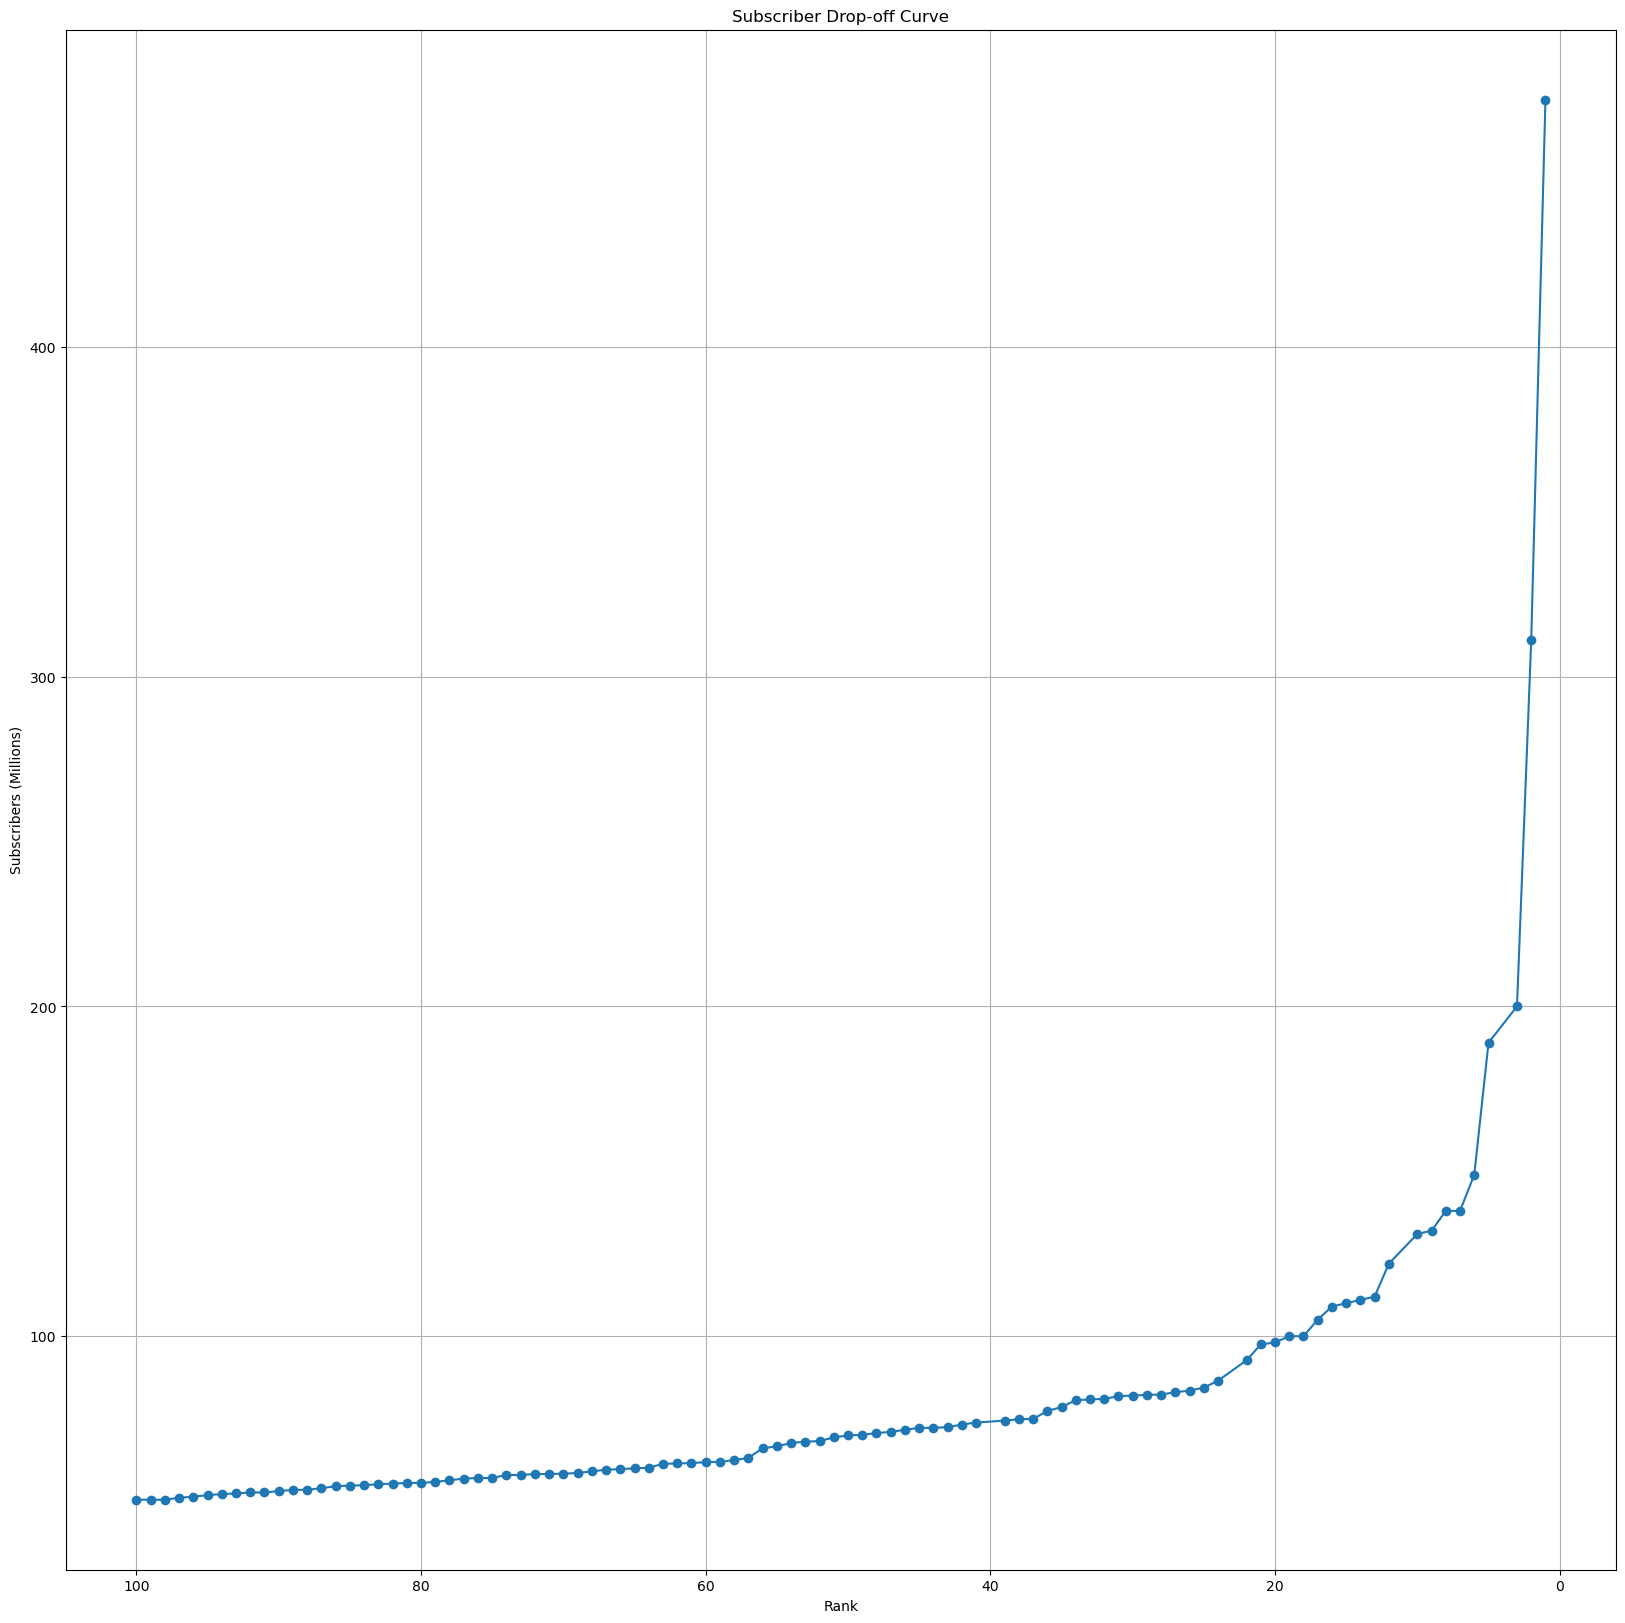

In [10]:
df_sorted = df.sort_values(by='subscribers', ascending=False)

plt.plot(df_sorted['rank'], df_sorted['subscribers'], marker='o')

plt.gca().invert_xaxis()
plt.title("Subscriber Drop-off Curve")
plt.xlabel("Rank")
plt.ylabel("Subscribers (Millions)")
plt.grid(True)
plt.show()

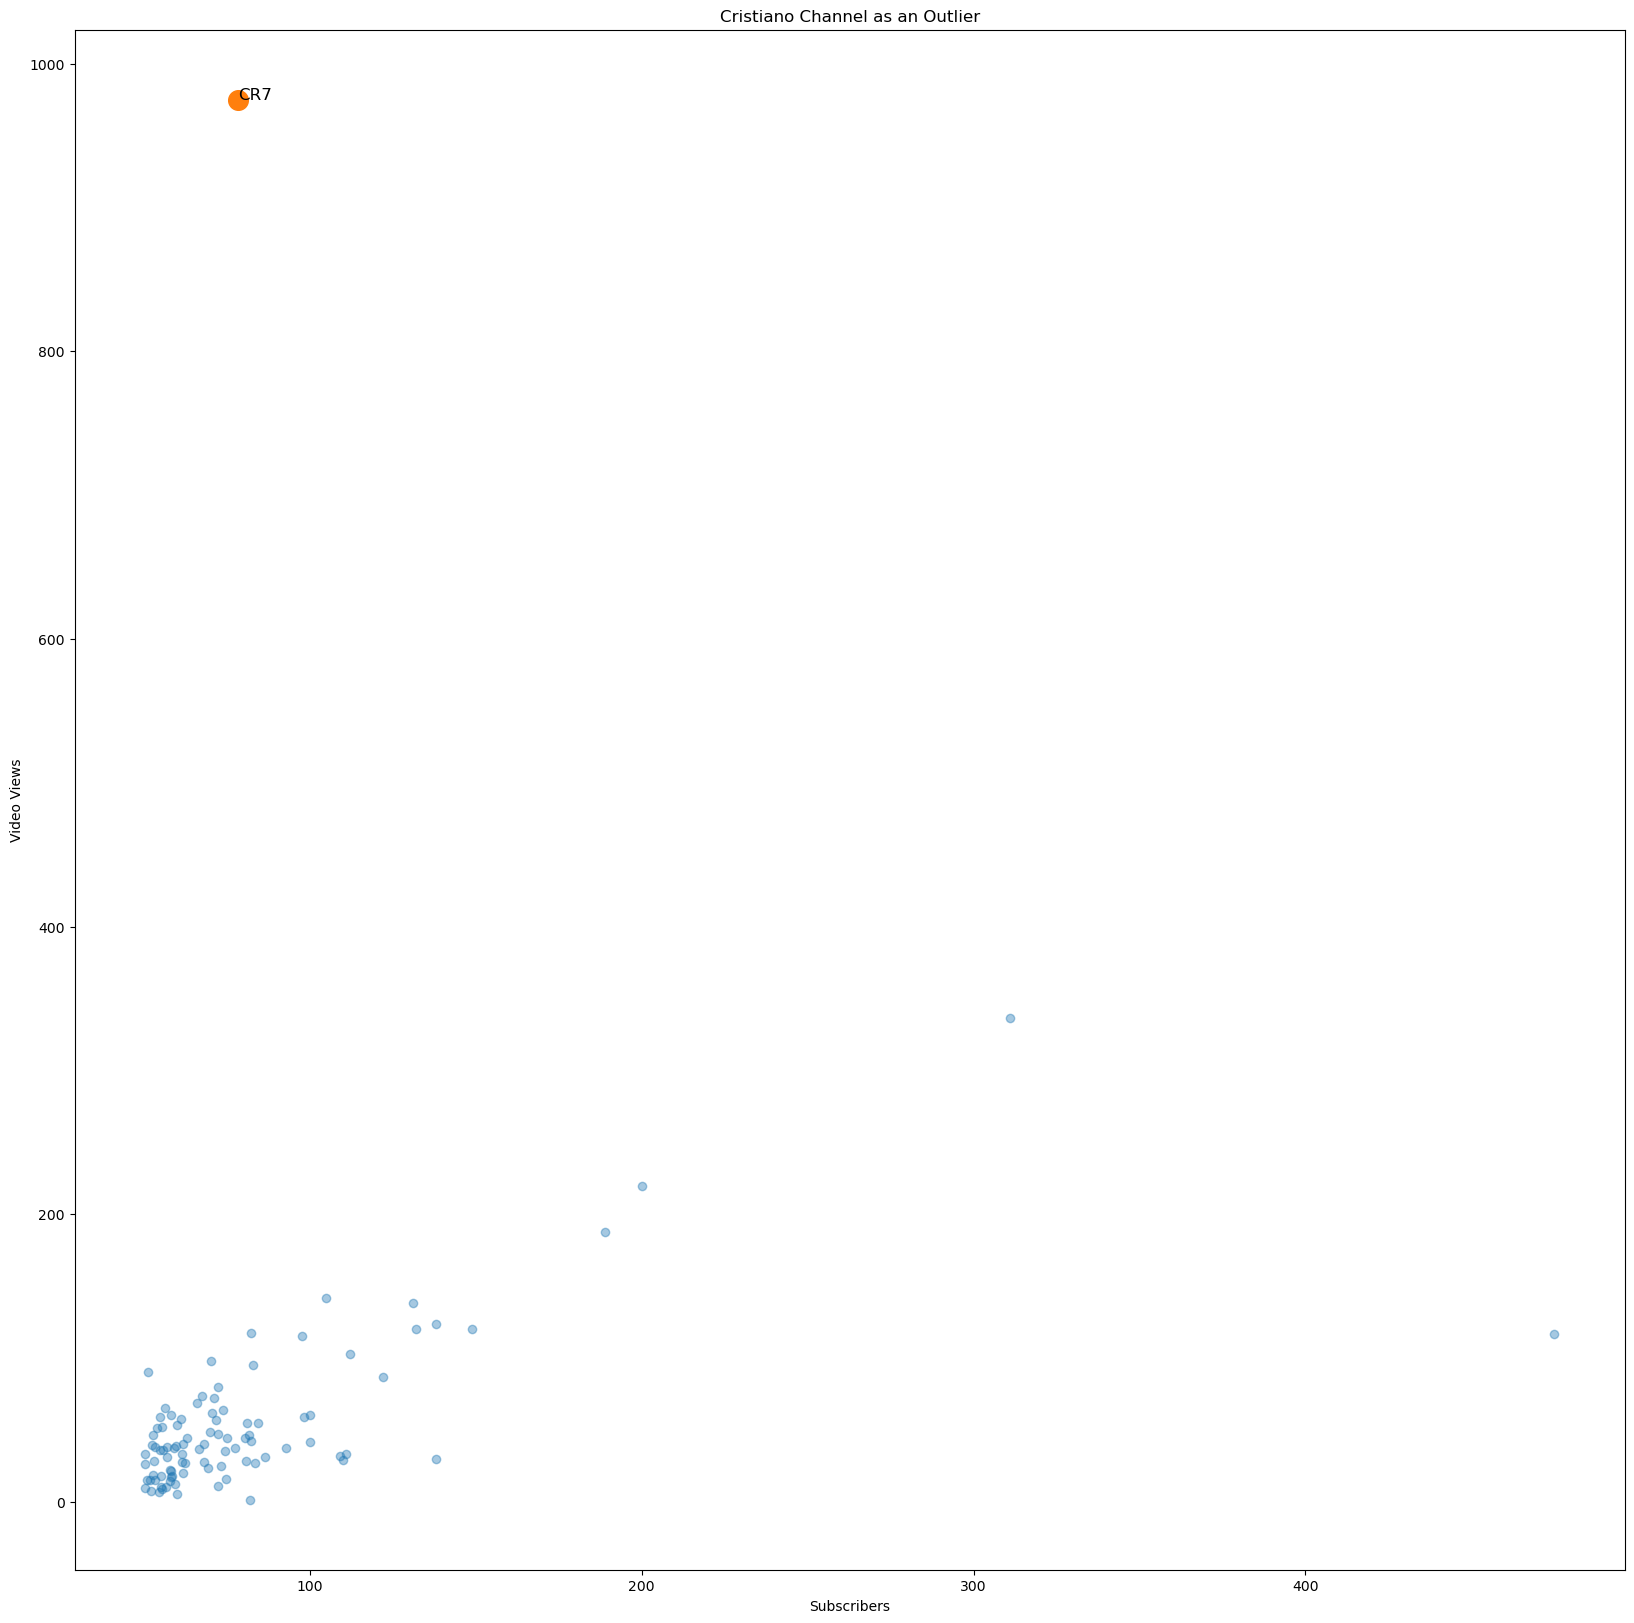

In [11]:
plt.scatter(df['subscribers'], df['video_views'], alpha=0.4)


cr7= df[df['channel'].str.contains('Cristiano')]
plt.scatter(cr7['subscribers'], cr7['video_views'], s=200)

plt.text(
    cr7['subscribers'].values[0], 
    cr7['video_views'].values[0], 
    "CR7", fontsize=12
)

plt.xlabel("Subscribers")
plt.ylabel("Video Views")
plt.title("Cristiano Channel as an Outlier")
plt.show()

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


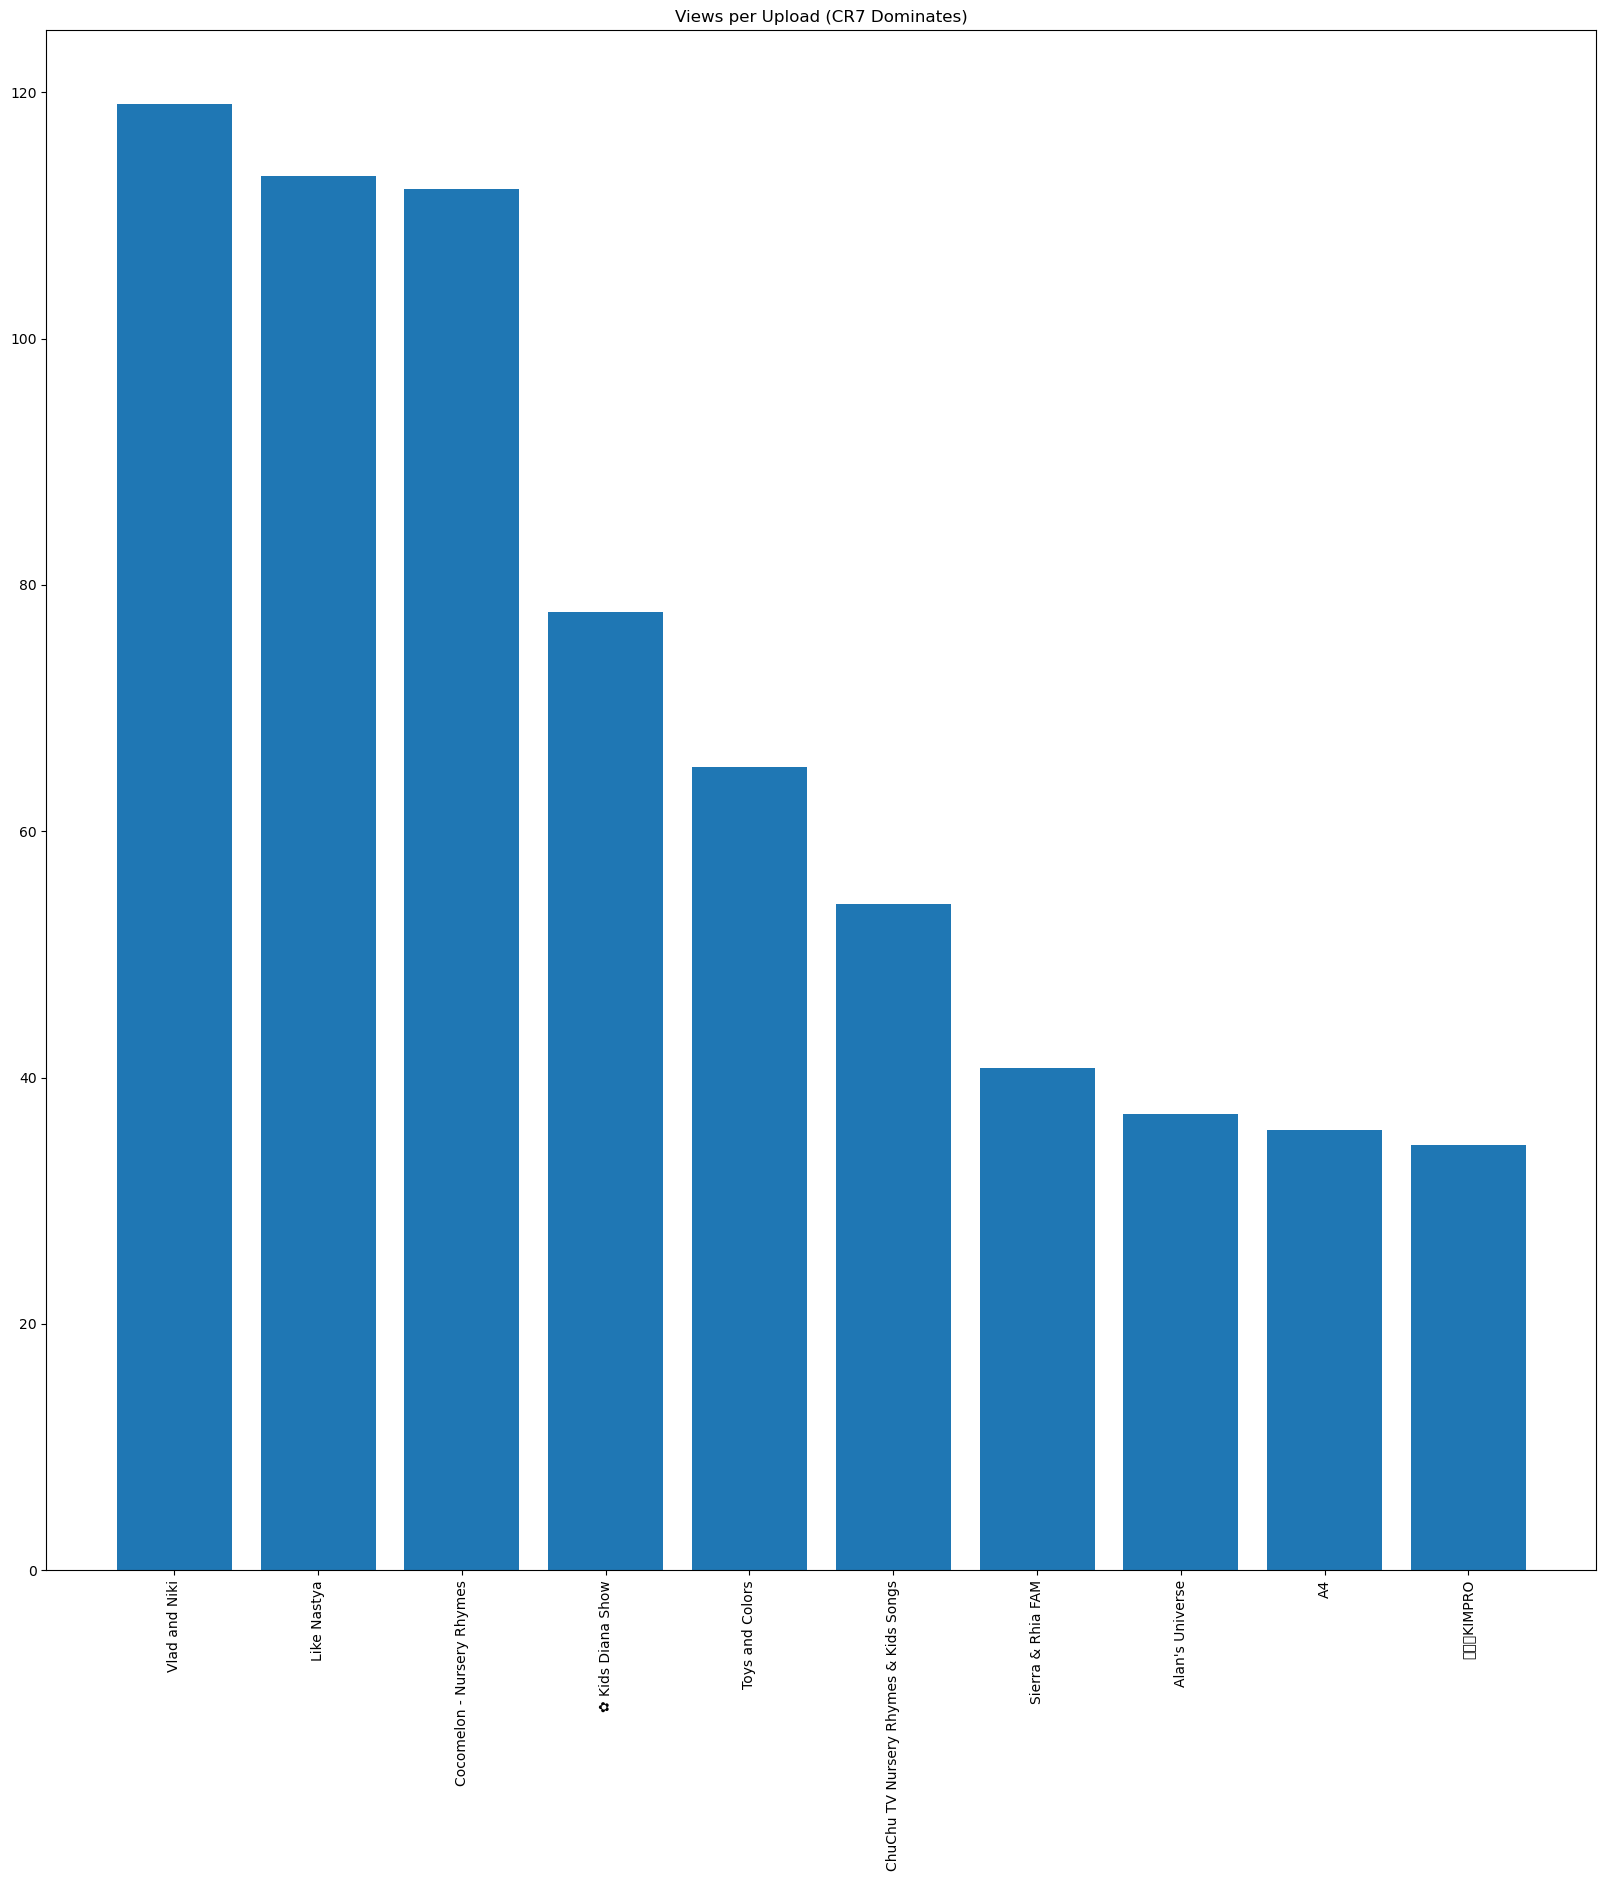

In [12]:
df['views_per_upload'] = df['video_views'] / df['uploads']

top_eff = df.sort_values(by='views_per_upload', ascending=False).head(10)

plt.bar(top_eff['channel'], top_eff['views_per_upload'])

plt.xticks(rotation=90)
plt.title("Views per Upload (CR7 Dominates)")
plt.show()

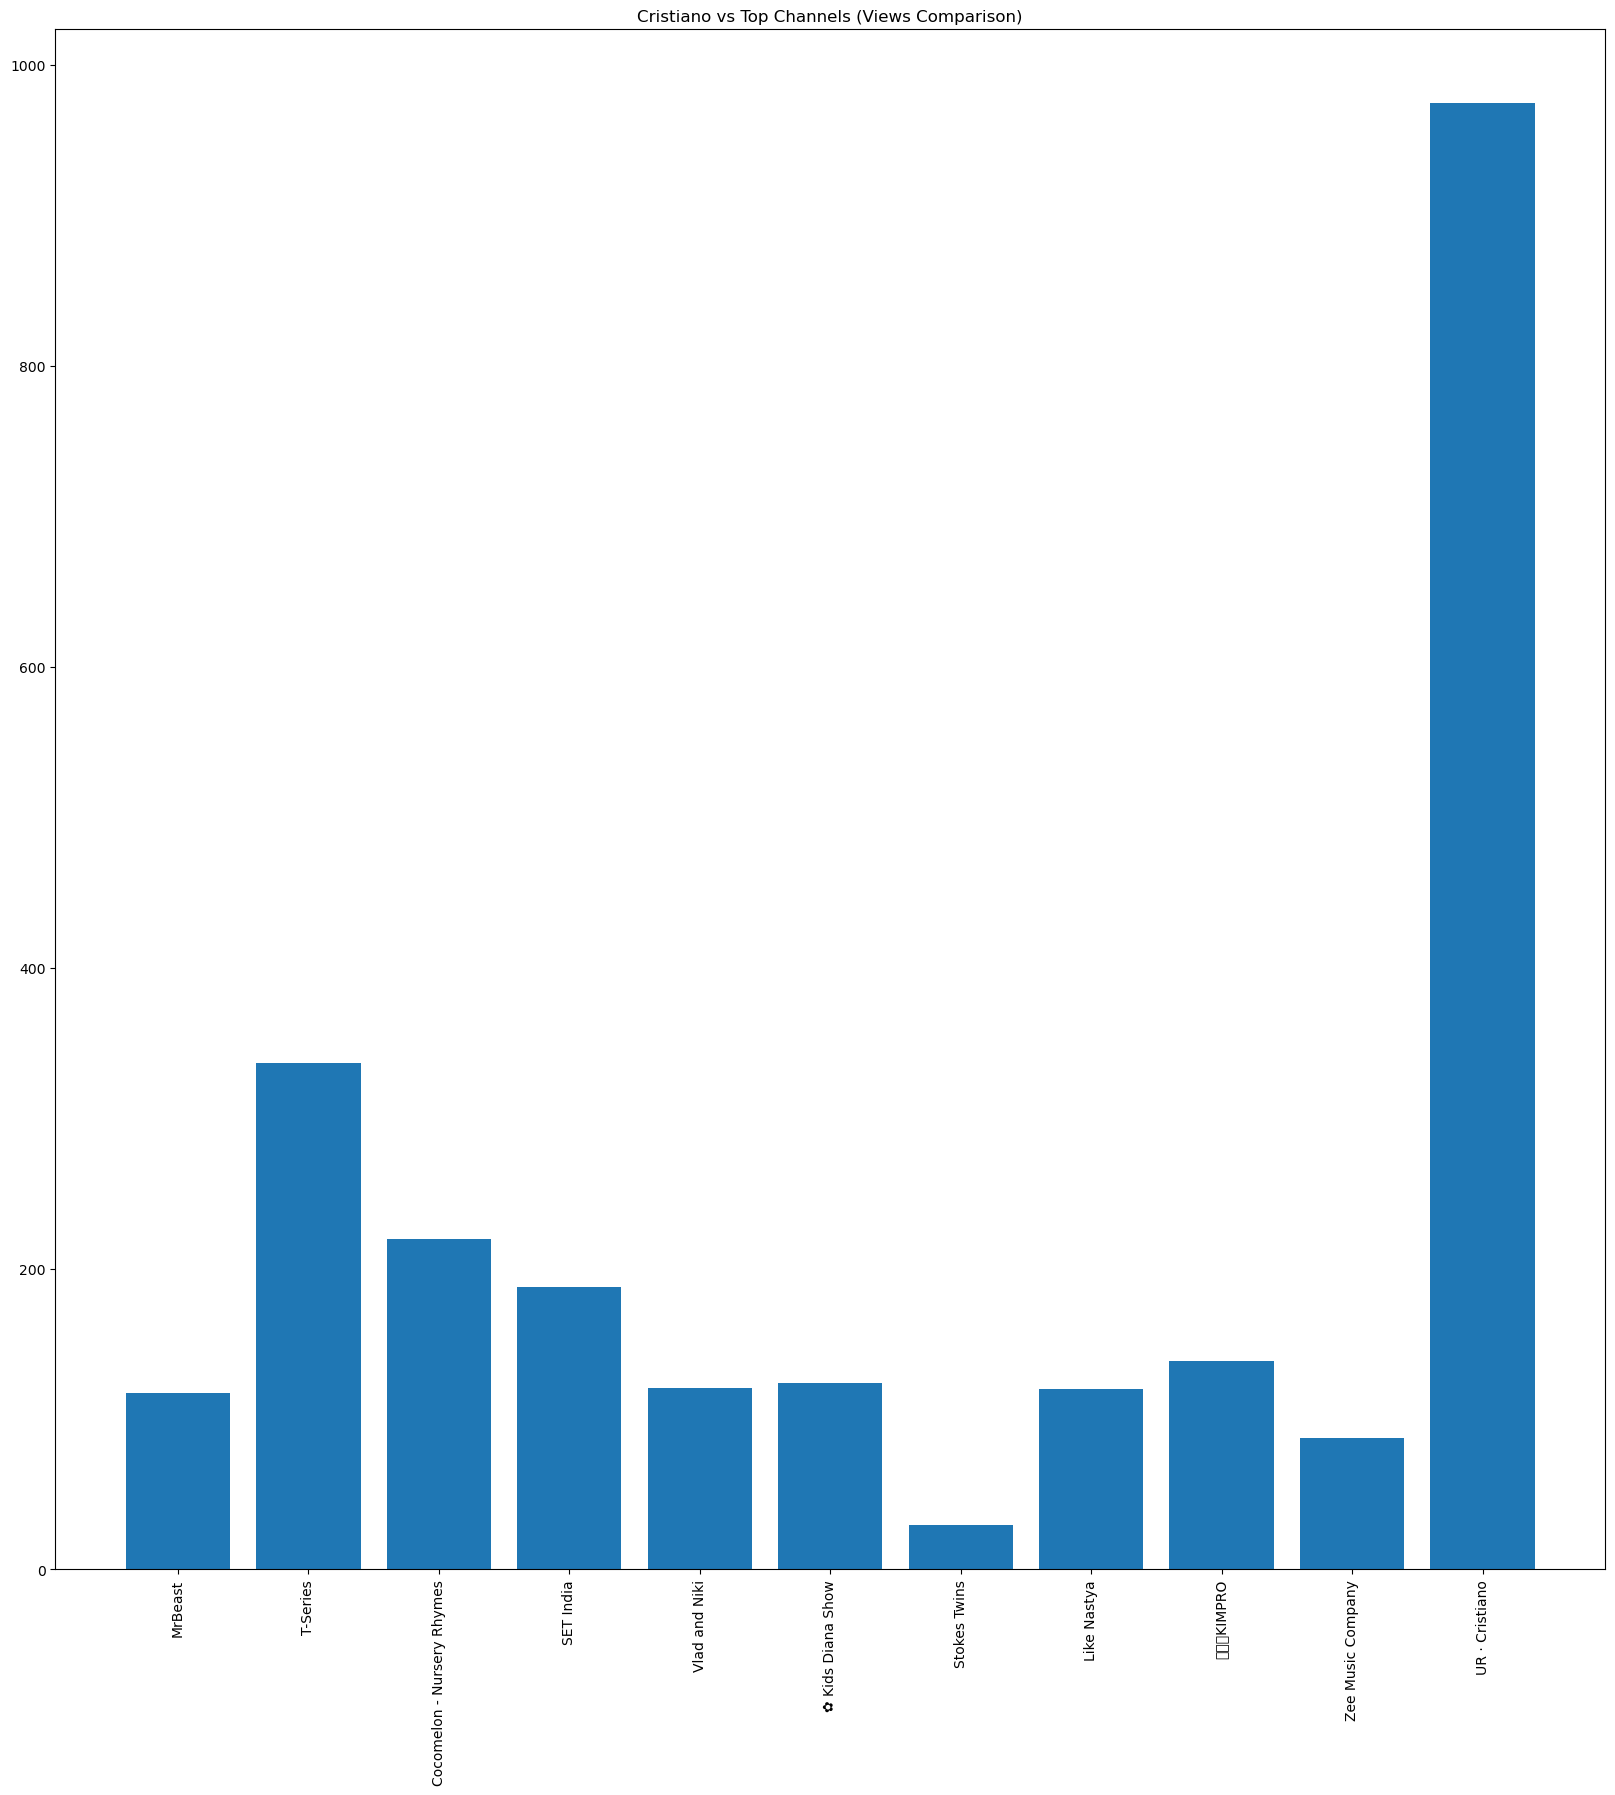

In [13]:
top10 = df.sort_values(by='subscribers', ascending=False).head(10)
cr7 = df[df['channel'].str.contains('Cristiano')]

compare = pd.concat([top10, cr7]).drop_duplicates()

plt.bar(compare['channel'], compare['video_views'])

plt.xticks(rotation=90)
plt.title("Cristiano vs Top Channels (Views Comparison)")
plt.show()

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12387 (\N{HIRAGANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12379 (\N{HIRAGANA LETTER SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively

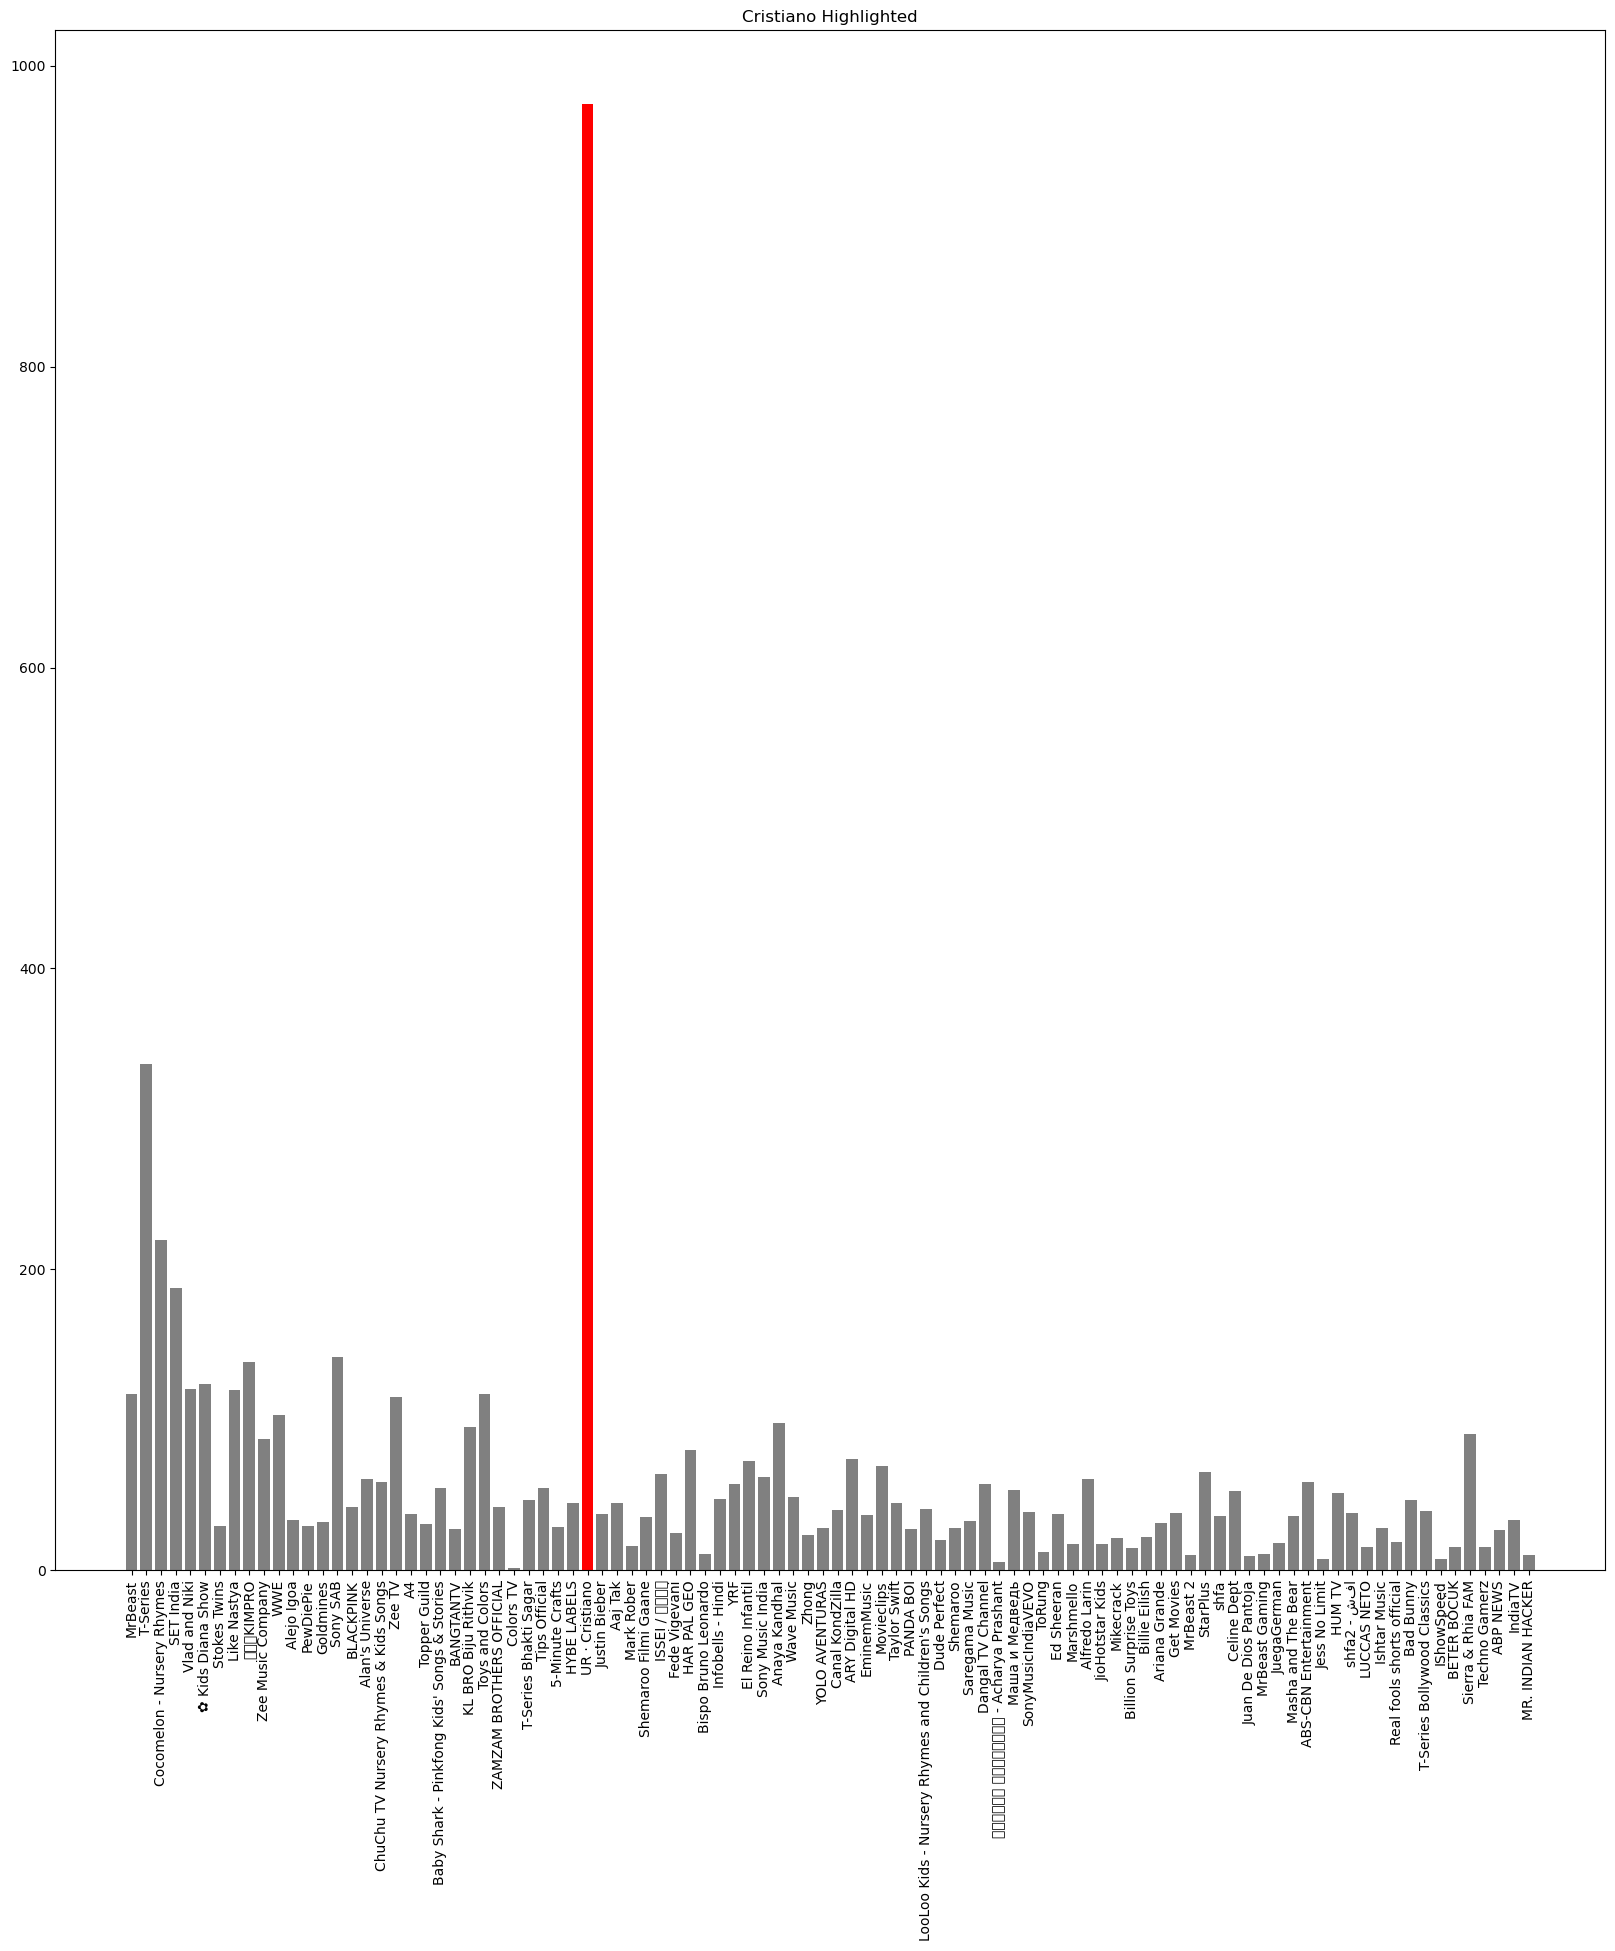

In [14]:
colors = ['grey'] * len(df)
cr7_index = df[df['channel'].str.contains('Cristiano')].index[0]
colors[cr7_index] = 'red'

plt.bar(df['channel'], df['video_views'], color=colors)

plt.xticks(rotation=90)
plt.title("Cristiano Highlighted")
plt.show()

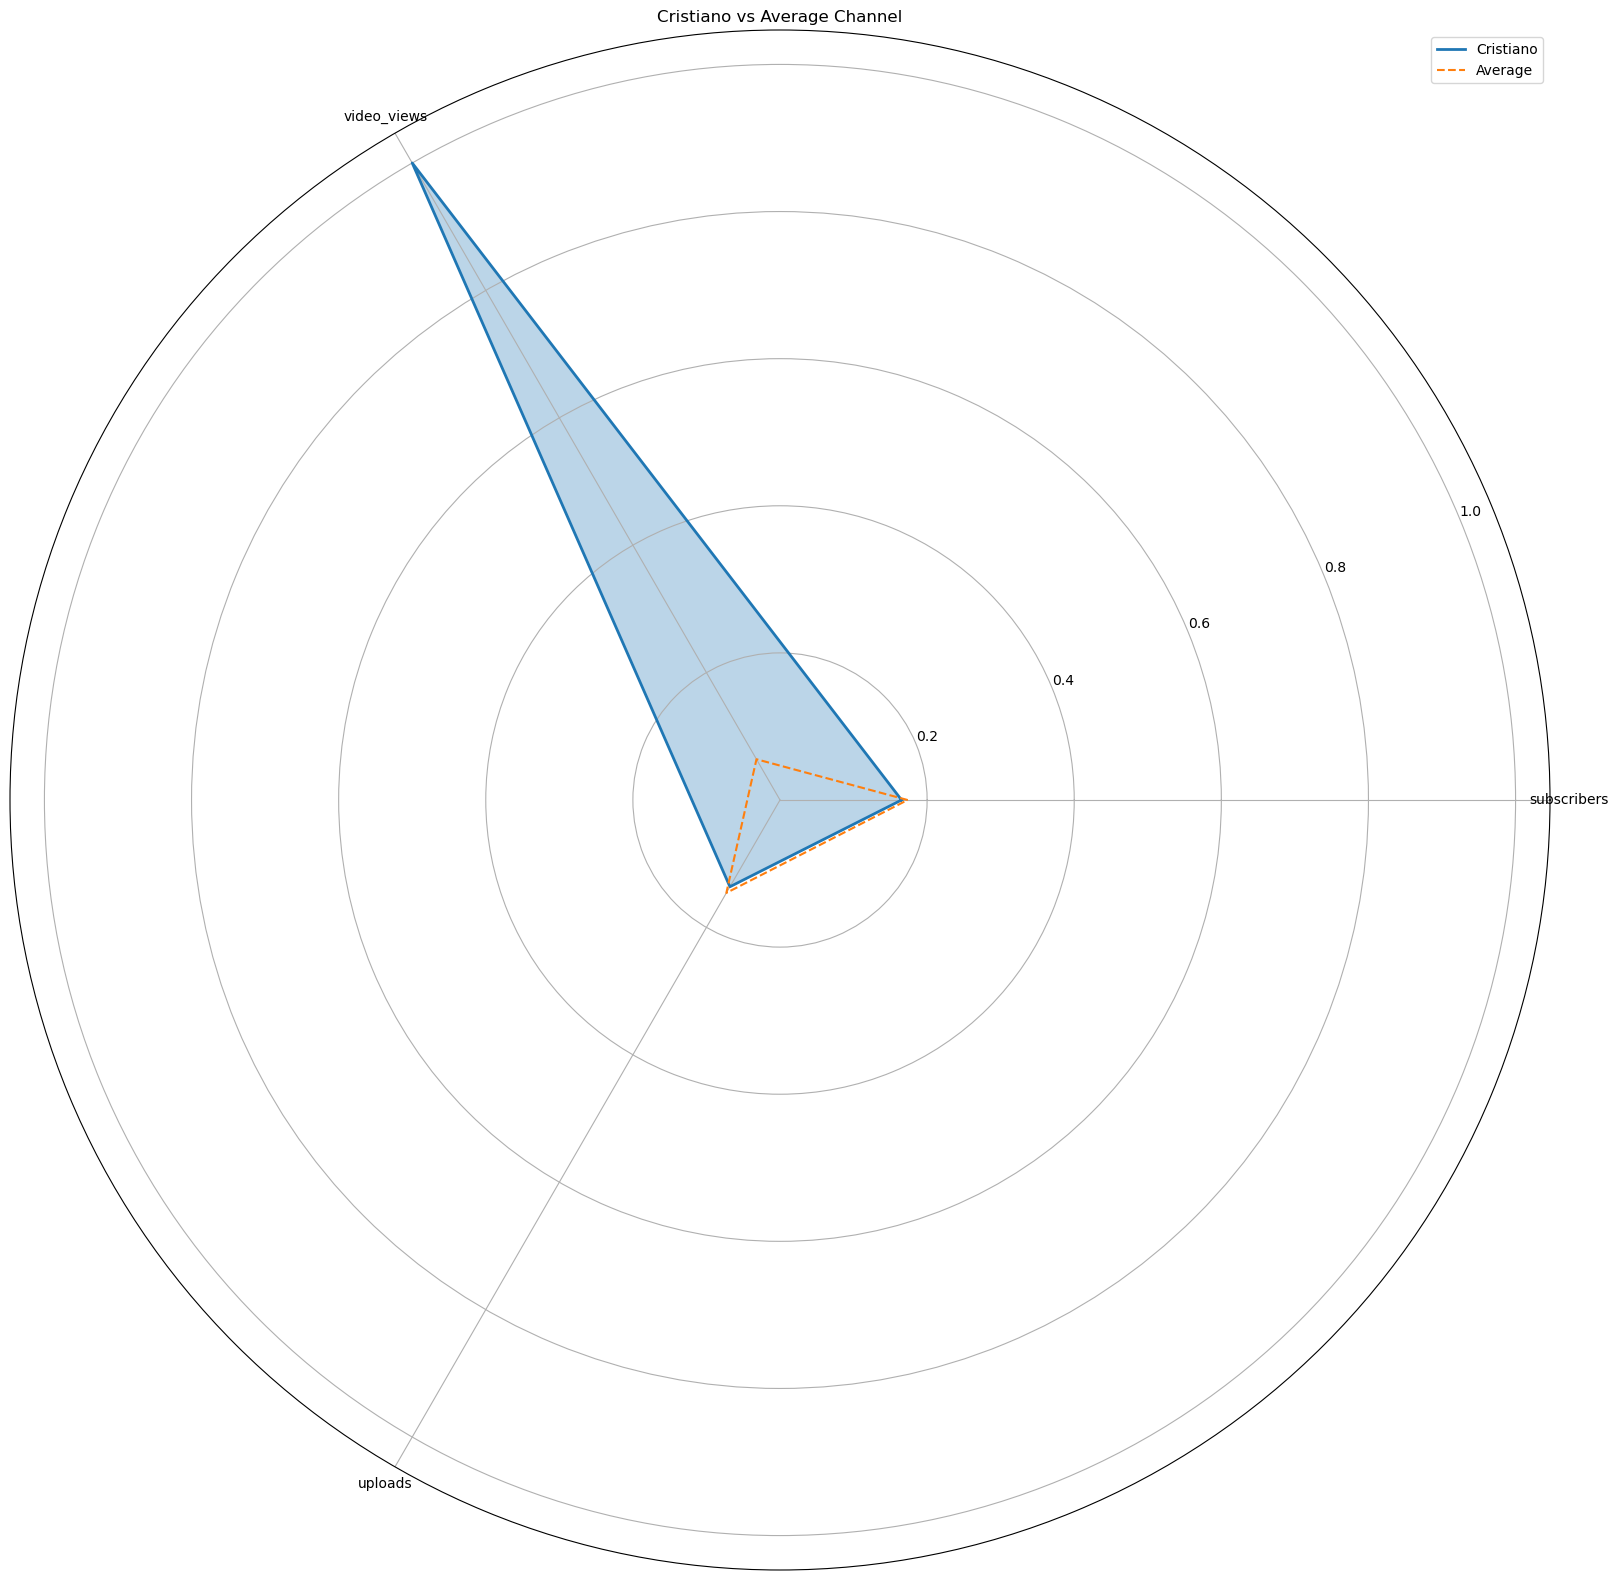

In [15]:

metrics = ['subscribers', 'video_views', 'uploads']


normalized = df.copy()
normalized[metrics] = df[metrics] / df[metrics].max()


cr7 = normalized[normalized['channel'].str.contains('Cristiano')].iloc[0]
cr7_values = cr7[metrics].values.tolist()
cr7_values += cr7_values[:1]


avg_values = normalized[metrics].mean().values.tolist()
avg_values += avg_values[:1]


angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]


plt.polar(angles, cr7_values, label='Cristiano', linewidth=2)
plt.fill(angles, cr7_values, alpha=0.3)

plt.polar(angles, avg_values, linestyle='--', label='Average')

plt.xticks(angles[:-1], metrics)
plt.legend()
plt.title("Cristiano vs Average Channel")

plt.show()

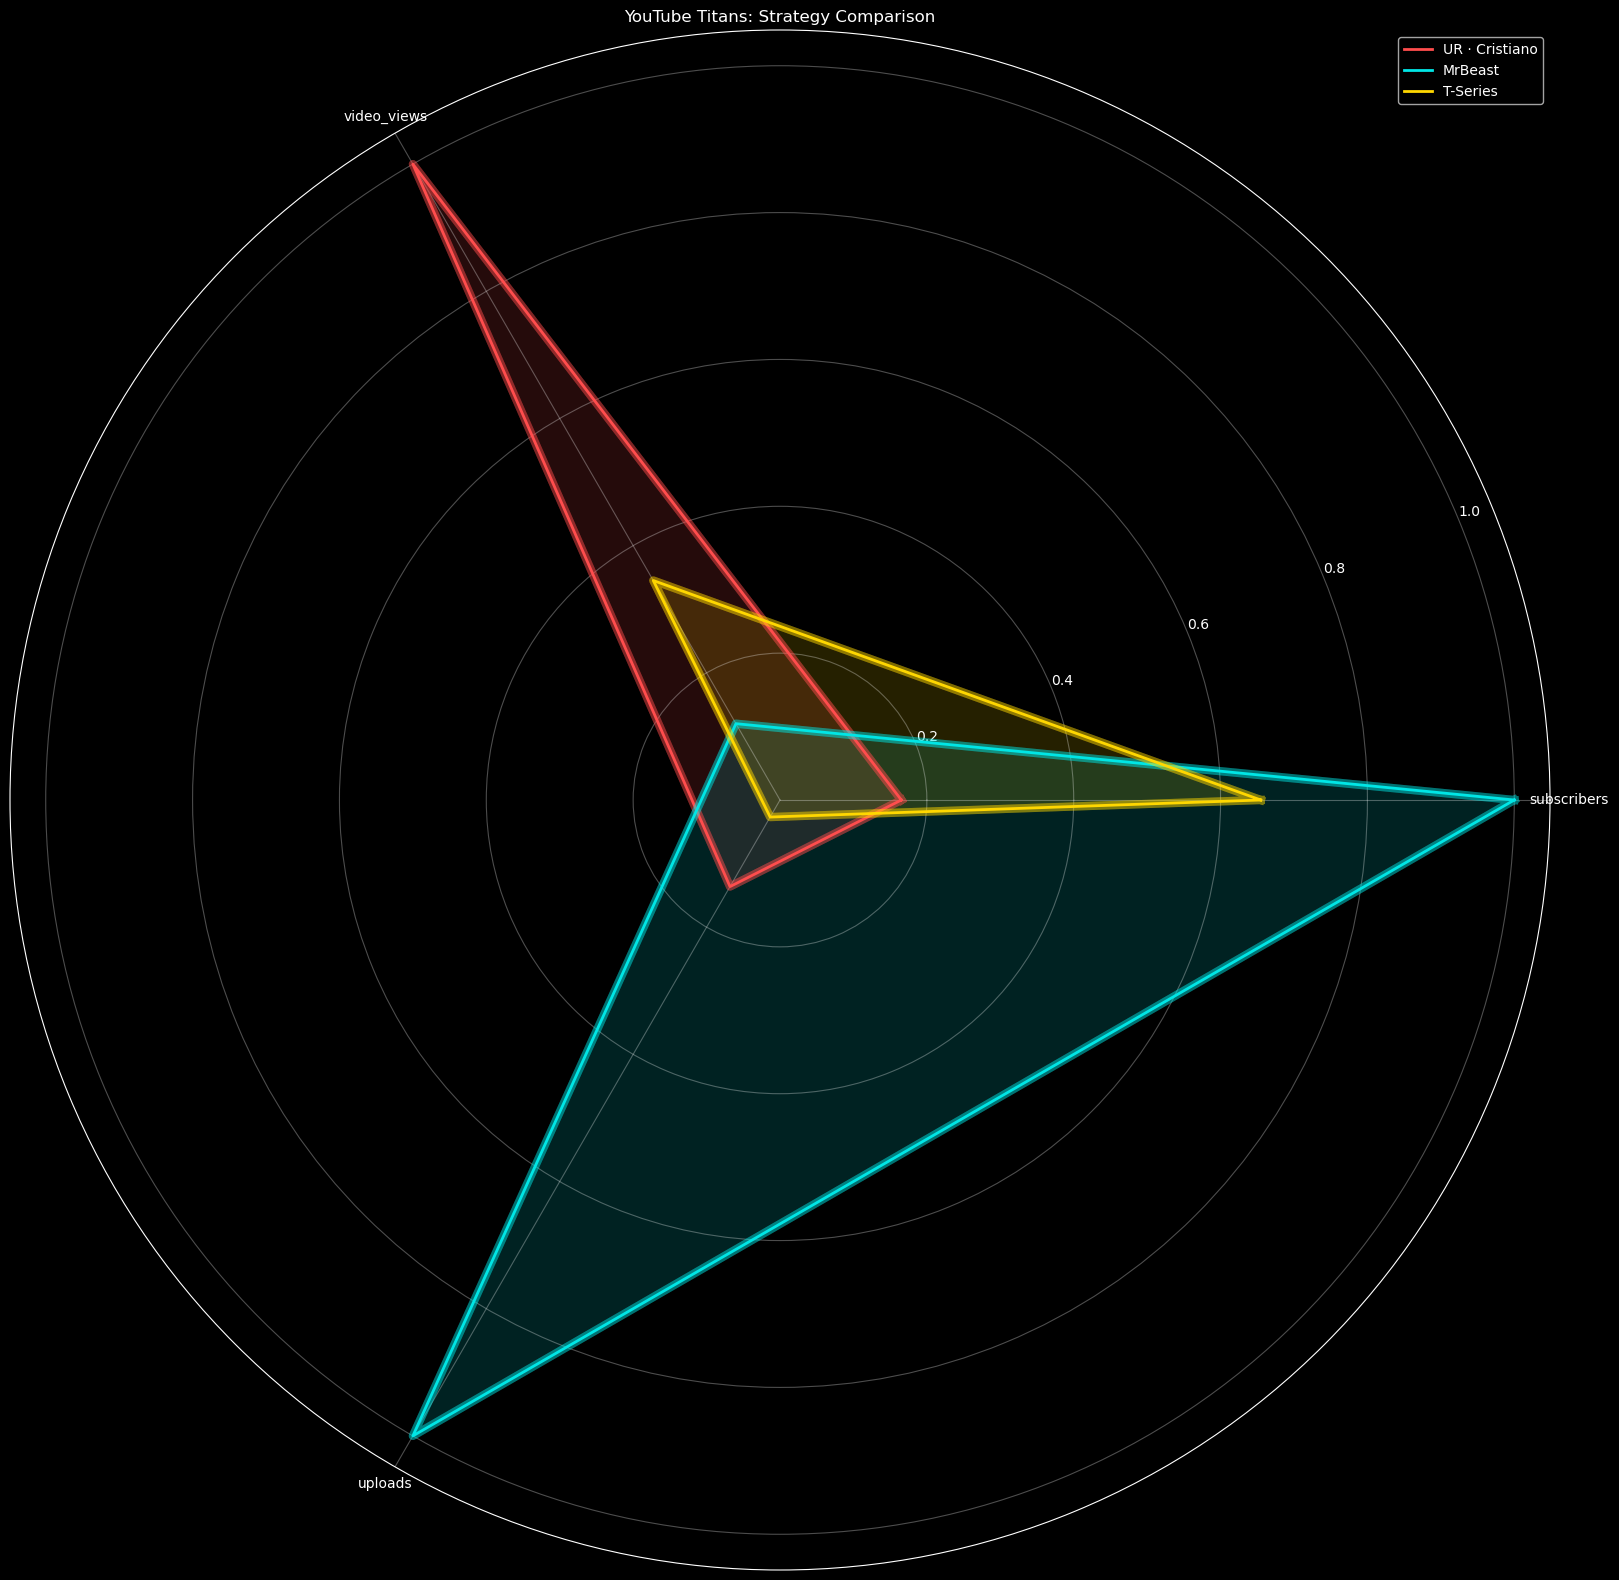

In [16]:


plt.style.use('dark_background')

channels = ['UR · Cristiano', 'MrBeast', 'T-Series']
metrics = ['subscribers', 'video_views', 'uploads']

normalized = df.copy()
normalized[metrics] = df[metrics] / df[metrics].max()


angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

colors = ['#ff4d4d', '#00e6e6', '#ffd700']

for i, channel in enumerate(channels):
    
    row = normalized[normalized['channel'] == channel].iloc[0] 
    values = row[metrics].values.tolist()
    values += values[:1]
    
    
    for alpha in [0.1, 0.2, 0.3]:
        plt.polar(angles, values, linewidth=6, alpha=alpha, color=colors[i])
    
    plt.polar(angles, values, linewidth=2, label=channel, color=colors[i])
    plt.fill(angles, values, alpha=0.15, color=colors[i])

plt.xticks(angles[:-1], metrics)
plt.title("YouTube Titans: Strategy Comparison")

plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.show()